# Stoppage Analysis

This notebook compares extracted stoppages from `processed_motion.csv` against the Harford audit extract.

The notebook is intentionally kept linear:

1. Load settings and helper functions.
2. Load extracted stoppages.
3. Load Harford stoppages.
4. Compare both records by nearest timestamp.
5. Repeat the comparison for videos in `stop_clips` only.
6. Extract motion and stop timelines, then detect duration-based overlaps.


## 1. Setup

Set file paths, comparison tolerances, and the timestamp assumptions used throughout the notebook.


In [63]:
from pathlib import Path
from zipfile import ZipFile, ZIP_DEFLATED
import xml.etree.ElementTree as ET
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Keep notebook tables and plots readable.
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)
plt.style.use("seaborn-v0_8-whitegrid")

# Work out the repo root from wherever the notebook is opened.
current_path = Path.cwd().resolve()
if current_path.name == "stoppage_detection":
    repo_root = current_path.parent
elif (current_path / "stoppage_detection").exists():
    repo_root = current_path
else:
    raise RuntimeError(
        "Open this notebook from the repo root or from the stoppage_detection folder. "
        f"Current directory was: {current_path}"
    )

stoppage_detection_dir = repo_root / "stoppage_detection"
processed_videos_path = stoppage_detection_dir / "processed_videos.csv"
processed_motion_path = stoppage_detection_dir / "processed_motion.csv"
stop_clips_dir = stoppage_detection_dir / "stop_clips"
output_dir = stoppage_detection_dir / "stoppage_analysis_output"
output_dir.mkdir(parents=True, exist_ok=True)

# Change this path when you want to switch between Harford extract versions.
harford_extract_path = stoppage_detection_dir / "data" / "Harford Extract 18th to 21st Line audit report Shrinwrapper_edited3.xlsx"
if not harford_extract_path.exists():
    raise FileNotFoundError(f"Harford extract not found: {harford_extract_path}")


# Edit these values if you want a tighter or looser comparison.
MATCH_TOLERANCE = pd.Timedelta("2min")
STOP_MERGE_GAP = pd.Timedelta("1min")
TIME_BIN = "1min"

# Apply this adjustment to Harford timestamps after reading the workbook.
# A negative value moves Harford stop times earlier.
HARFORD_TIME_OFFSET = pd.Timedelta(minutes=0)
HARFORD_TIME_OFFSET_LABEL = "0 minutes"

# Video filenames are treated as UTC timestamps.
# Harford Excel times are treated as local site timestamps.
LOCAL_TIMEZONE = "Europe/London"
EXTRACTED_TIMESTAMPS_ARE_UTC = True

print(f"Processed videos: {processed_videos_path}")
print(f"Processed motion: {processed_motion_path}")
print(f"Harford extract:  {harford_extract_path}")
print(f"Output folder:    {output_dir}")
print(f"Match tolerance:  {MATCH_TOLERANCE}")
print(f"Stop merge gap:   {STOP_MERGE_GAP}")
print(f"Harford offset:   {HARFORD_TIME_OFFSET_LABEL}")
print(f"Local timezone:   {LOCAL_TIMEZONE}")


Processed videos: C:\Users\TimKitchen\OneDrive\OneDrive - PurpleSector\03 Project Specific Documents\24H_INSIGHTS\24H_Insights\motion_detection\processed_videos.csv
Processed motion: C:\Users\TimKitchen\OneDrive\OneDrive - PurpleSector\03 Project Specific Documents\24H_INSIGHTS\24H_Insights\motion_detection\processed_motion.csv
Harford extract:  C:\Users\TimKitchen\OneDrive\OneDrive - PurpleSector\03 Project Specific Documents\24H_INSIGHTS\24H_Insights\motion_detection\data\Harford Extract 18th to 21st Line audit report Shrinwrapper_edited3.xlsx
Output folder:    C:\Users\TimKitchen\OneDrive\OneDrive - PurpleSector\03 Project Specific Documents\24H_INSIGHTS\24H_Insights\motion_detection\stoppage_analysis_output
Match tolerance:  0 days 00:02:00
Stop merge gap:   0 days 00:01:00
Harford offset:   0 minutes
Local timezone:   Europe/London


## 2. Helper Functions

These functions keep the later chapters short. They only do small, specific jobs.


In [64]:
def extract_video_datetime(video_name_series):
    """Extract datetimes from names like camera_2026-06-18_21-00-38_123456.ts."""
    # Pull out the date and time parts from each filename.
    extracted_parts = video_name_series.astype(str).str.extract(
        r"(?P<date>\d{4}-\d{2}-\d{2})_(?P<time>\d{2}-\d{2}-\d{2})"
    )

    # Convert HH-MM-SS into HH:MM:SS so pandas can parse it.
    normal_time_text = extracted_parts["time"].fillna("").str.replace("-", ":", regex=False)
    datetime_text = extracted_parts["date"].fillna("") + " " + normal_time_text

    return pd.to_datetime(datetime_text, format="%Y-%m-%d %H:%M:%S", errors="coerce")


def convert_extracted_timestamp_to_local_time(timestamp_series):
    """Convert video filename timestamps into the same local time basis as Harford."""
    # Keep timestamps unchanged if filenames are already local/site time.
    if not EXTRACTED_TIMESTAMPS_ARE_UTC:
        return timestamp_series

    # Interpret the filename timestamp as UTC.
    utc_times = timestamp_series.dt.tz_localize("UTC")

    # Convert UTC into the local timezone used by the Harford report.
    local_times = utc_times.dt.tz_convert(LOCAL_TIMEZONE)

    # Harford Excel timestamps are timezone-naive, so remove timezone metadata after conversion.
    return local_times.dt.tz_localize(None)


def read_first_csv_field(csv_path):
    """Read the first field from each non-empty CSV data row."""
    # processed_motion.csv can have trailing empty columns, so this safely reads the filename field.
    first_fields = []
    with open(csv_path, "r", encoding="utf-8") as csv_file:
        csv_file.readline()

        for line in csv_file:
            clean_line = line.strip()
            if not clean_line:
                continue

            first_field = clean_line.split(",", 1)[0]
            if not first_field:
                continue

            first_fields.append(first_field)

    return pd.Series(first_fields, name="video_name")


def build_extracted_stop_intervals(extracted_records_df):
    """Convert detected stop rows into exact local stop intervals."""
    # Keep only rows where the motion pipeline detected a stop.
    stop_rows_df = extracted_records_df[extracted_records_df["stop_detected"] == 1].copy()
    if stop_rows_df.empty:
        return pd.DataFrame()

    # The filename timestamp is the video start time.
    stop_rows_df = stop_rows_df.rename(columns={"stop_time": "video_start_time"})

    # Missing offsets are treated as zero so every detected row has an interval.
    start_offset_seconds = stop_rows_df["stop_start_seconds"].fillna(0)
    end_offset_seconds = stop_rows_df["stop_end_seconds"]

    # If stop_end_seconds is missing, fall back to start + duration.
    duration_seconds = stop_rows_df["stop_duration_seconds"].fillna(0)
    end_offset_seconds = end_offset_seconds.fillna(start_offset_seconds + duration_seconds)
    end_offset_seconds = end_offset_seconds.fillna(start_offset_seconds)

    # Convert offsets into local timestamps.
    stop_rows_df["stop_time"] = stop_rows_df["video_start_time"] + pd.to_timedelta(
        start_offset_seconds,
        unit="s",
    )
    stop_rows_df["stop_end_time"] = stop_rows_df["video_start_time"] + pd.to_timedelta(
        end_offset_seconds,
        unit="s",
    )

    # Make zero-length or inverted intervals visible as a one-second interval.
    invalid_interval = stop_rows_df["stop_end_time"] <= stop_rows_df["stop_time"]
    stop_rows_df.loc[invalid_interval, "stop_end_time"] = (
        stop_rows_df.loc[invalid_interval, "stop_time"] + pd.Timedelta(seconds=1)
    )

    # Add a simple interval id for review and overlap matching.
    stop_rows_df = stop_rows_df.sort_values("stop_time").reset_index(drop=True)
    stop_rows_df["extracted_interval_id"] = np.arange(1, len(stop_rows_df) + 1)
    stop_rows_df["extracted_interval_seconds"] = (
        stop_rows_df["stop_end_time"] - stop_rows_df["stop_time"]
    ).dt.total_seconds()

    return stop_rows_df


def group_stop_intervals_until_motion_resumes(stop_interval_df):
    """Group stop detections until the previous stop interval has resumed motion."""
    if stop_interval_df.empty:
        return pd.DataFrame(columns=[
            "extracted_stop_id",
            "stop_time",
            "stop_end_time",
            "source_detection_count",
            "source_first_video_name",
            "source_last_video_name",
        ])

    # Work in true stop-start order, not video-start order.
    ordered_df = stop_interval_df.sort_values("stop_time").reset_index(drop=True).copy()

    grouped_rows = []
    current_group_rows = []
    current_group_end_time = pd.NaT

    for row in ordered_df.itertuples(index=False):
        row_start_time = row.stop_time
        row_end_time = row.stop_end_time

        # Start the first grouped stoppage.
        if not current_group_rows:
            current_group_rows = [row]
            current_group_end_time = row_end_time
            continue

        # Same stoppage if the next detected stop starts before motion resumed.
        if row_start_time <= current_group_end_time:
            current_group_rows.append(row)
            if row_end_time > current_group_end_time:
                current_group_end_time = row_end_time
            continue

        # Motion had resumed before this row started, so the previous stoppage is finished.
        grouped_rows.append(current_group_rows)
        current_group_rows = [row]
        current_group_end_time = row_end_time

    # Add the final open group.
    if current_group_rows:
        grouped_rows.append(current_group_rows)

    # Collapse each grouped stoppage into one row.
    output_rows = []
    for stop_id, group_rows in enumerate(grouped_rows, start=1):
        first_row = group_rows[0]
        last_row = group_rows[-1]
        group_end_time = max(row.stop_end_time for row in group_rows)

        output_rows.append({
            "extracted_stop_id": stop_id,
            "stop_time": first_row.stop_time,
            "stop_end_time": group_end_time,
            "source_detection_count": int(len(group_rows)),
            "source_first_video_name": first_row.video_name,
            "source_last_video_name": last_row.video_name,
        })

    return pd.DataFrame(output_rows)


def repair_xlsx_print_titles_if_needed(file_path):
    """Create a repaired xlsx copy when invalid print-title metadata blocks openpyxl."""
    # Only xlsx files are zip packages with workbook XML to repair.
    if file_path.suffix.lower() != ".xlsx":
        return file_path

    repaired_path = output_dir / f"{file_path.stem}_openpyxl_repaired.xlsx"

    # Read the workbook metadata that can contain invalid print-title definitions.
    with ZipFile(file_path, "r") as input_zip:
        workbook_xml = input_zip.read("xl/workbook.xml")

    ET.register_namespace("", "http://schemas.openxmlformats.org/spreadsheetml/2006/main")
    root = ET.fromstring(workbook_xml)
    namespace = {"main": "http://schemas.openxmlformats.org/spreadsheetml/2006/main"}
    defined_names = root.find("main:definedNames", namespace)

    removed_bad_name = False
    if defined_names is not None:
        for defined_name in list(defined_names):
            name = defined_name.attrib.get("name", "")
            value = (defined_name.text or "").strip()

            # Excel can save an invalid print-title reference as #N/A.
            # openpyxl refuses to load that workbook, even though the table data is fine.
            if name == "_xlnm.Print_Titles" and value == "#N/A":
                defined_names.remove(defined_name)
                removed_bad_name = True

        # Remove the empty parent node if that was the only defined name.
        if len(list(defined_names)) == 0:
            root.remove(defined_names)

    # If there was nothing to repair, use the original file.
    if not removed_bad_name:
        return file_path

    repaired_workbook_xml = ET.tostring(root, encoding="utf-8", xml_declaration=True)

    # Copy the xlsx zip package, replacing only xl/workbook.xml.
    with ZipFile(file_path, "r") as input_zip:
        with ZipFile(repaired_path, "w", compression=ZIP_DEFLATED) as output_zip:
            for item in input_zip.infolist():
                if item.filename == "xl/workbook.xml":
                    output_zip.writestr(item, repaired_workbook_xml)
                else:
                    output_zip.writestr(item, input_zip.read(item.filename))

    return repaired_path


def read_harford_workbook(file_path):
    """Read the Harford workbook, repairing known xlsx metadata issues if needed."""
    try:
        return pd.read_excel(file_path, header=None)
    except ValueError as error:
        # openpyxl fails on some workbooks that contain invalid print-title metadata.
        if file_path.suffix.lower() != ".xlsx" or "could not assign names" not in str(error):
            raise

        repaired_path = repair_xlsx_print_titles_if_needed(file_path)
        print(f"Repaired invalid Excel print-title metadata: {repaired_path}")
        return pd.read_excel(repaired_path, header=None)
    except AssertionError as error:
        raise ValueError(
            "Pandas cannot read this Harford .xls workbook. "
            "This usually means the .xls file is malformed or saved in a format xlrd cannot parse. "
            "Open it in Excel, Save As .xlsx, then update harford_extract_path in Chapter 1."
        ) from error


def find_harford_header_row(raw_df, rows_to_check=30):
    """Find the row that contains the real Harford table headers."""
    # Search near the top of the workbook for the expected table headings.
    rows_to_check = min(rows_to_check, len(raw_df))
    for row_index in range(rows_to_check):
        row_values = [str(value).strip().lower() for value in raw_df.iloc[row_index].tolist()]
        if "time" in row_values and "period" in row_values and "type" in row_values:
            return int(row_index)

    raise ValueError("Could not find the Harford table header row")


def promote_header_row(raw_df, header_row):
    """Use one row from a raw workbook as the DataFrame header."""
    # Clean the raw column names.
    raw_column_names = raw_df.iloc[header_row].astype(str).str.strip().tolist()

    # Make duplicate column names unique, for example Time and Time.1.
    clean_column_names = []
    seen_counts = {}
    for column_name in raw_column_names:
        if column_name == "" or column_name.lower() == "nan":
            column_name = "unnamed"

        seen_counts[column_name] = seen_counts.get(column_name, 0) + 1
        if seen_counts[column_name] == 1:
            clean_column_names.append(column_name)
        else:
            clean_column_names.append(f"{column_name}.{seen_counts[column_name] - 1}")

    # Keep only rows below the header.
    table_df = raw_df.iloc[header_row + 1:].copy()
    table_df.columns = clean_column_names
    return table_df.dropna(how="all").reset_index(drop=True)


def compare_stops_by_time(extracted_stops_df, harford_stops_df, tolerance):
    """Match extracted and Harford stops by nearest timestamp inside the shared time window."""
    if extracted_stops_df.empty:
        raise ValueError("No extracted stoppages were available for comparison")
    if harford_stops_df.empty:
        raise ValueError("No Harford stoppages were available for comparison")

    # Compare only the time range where both records exist.
    window_start = max(extracted_stops_df["stop_time"].min(), harford_stops_df["harford_time"].min())
    window_end = min(extracted_stops_df["stop_time"].max(), harford_stops_df["harford_time"].max())

    extracted_window_df = extracted_stops_df[
        (extracted_stops_df["stop_time"] >= window_start)
        & (extracted_stops_df["stop_time"] <= window_end)
    ].copy()
    harford_window_df = harford_stops_df[
        (harford_stops_df["harford_time"] >= window_start)
        & (harford_stops_df["harford_time"] <= window_end)
    ].copy()

    # merge_asof requires both timestamp columns to use the same datetime precision.
    extracted_window_df["stop_time"] = pd.to_datetime(extracted_window_df["stop_time"]).astype("datetime64[ns]")
    harford_window_df["harford_time"] = pd.to_datetime(harford_window_df["harford_time"]).astype("datetime64[ns]")

    # Match each extracted stoppage to the nearest Harford stoppage.
    extracted_to_harford_df = pd.merge_asof(
        extracted_window_df.sort_values("stop_time"),
        harford_window_df.sort_values("harford_time"),
        left_on="stop_time",
        right_on="harford_time",
        direction="nearest",
        tolerance=tolerance,
        suffixes=("_extracted", "_harford"),
    )
    extracted_to_harford_df["matched_harford_stop"] = extracted_to_harford_df["harford_time"].notna()
    extracted_to_harford_df["time_difference_seconds"] = (
        extracted_to_harford_df["harford_time"] - extracted_to_harford_df["stop_time"]
    ).dt.total_seconds()
    extracted_to_harford_df["absolute_time_difference_seconds"] = extracted_to_harford_df["time_difference_seconds"].abs()

    # Match each Harford stoppage back to the nearest extracted stoppage.
    harford_to_extracted_df = pd.merge_asof(
        harford_window_df.sort_values("harford_time"),
        extracted_window_df.sort_values("stop_time"),
        left_on="harford_time",
        right_on="stop_time",
        direction="nearest",
        tolerance=tolerance,
        suffixes=("_harford", "_extracted"),
    )
    harford_to_extracted_df["matched_extracted_stop"] = harford_to_extracted_df["stop_time"].notna()
    harford_to_extracted_df["time_difference_seconds"] = (
        harford_to_extracted_df["stop_time"] - harford_to_extracted_df["harford_time"]
    ).dt.total_seconds()
    harford_to_extracted_df["absolute_time_difference_seconds"] = harford_to_extracted_df["time_difference_seconds"].abs()

    return {
        "window_start": window_start,
        "window_end": window_end,
        "extracted_window_df": extracted_window_df,
        "harford_window_df": harford_window_df,
        "extracted_to_harford_df": extracted_to_harford_df,
        "harford_to_extracted_df": harford_to_extracted_df,
    }


def make_summary_df(comparison, label):
    """Create a small summary table for one comparison run."""
    extracted_count = len(comparison["extracted_window_df"])
    harford_count = len(comparison["harford_window_df"])
    extracted_matched_count = int(comparison["extracted_to_harford_df"]["matched_harford_stop"].sum())
    harford_matched_count = int(comparison["harford_to_extracted_df"]["matched_extracted_stop"].sum())

    return pd.DataFrame([
        ("comparison_label", label),
        ("comparison_window_start", comparison["window_start"]),
        ("comparison_window_end", comparison["window_end"]),
        ("match_tolerance", str(MATCH_TOLERANCE)),
        ("stop_merge_gap", str(STOP_MERGE_GAP)),
        ("local_timezone", LOCAL_TIMEZONE),
        ("extracted_filename_timestamps_treated_as_utc", EXTRACTED_TIMESTAMPS_ARE_UTC),
        ("harford_timestamps_treated_as", "local/site Excel time"),
        ("extracted_stoppage_count", extracted_count),
        ("harford_stop_count", harford_count),
        ("extracted_stoppages_matched_to_harford", extracted_matched_count),
        ("extracted_stoppages_not_matched_to_harford", extracted_count - extracted_matched_count),
        ("harford_stops_matched_to_extracted_stoppages", harford_matched_count),
        ("harford_stops_not_matched_to_extracted_stoppages", harford_count - harford_matched_count),
        ("extracted_stoppage_match_rate", extracted_matched_count / extracted_count if extracted_count else np.nan),
        ("harford_match_rate", harford_matched_count / harford_count if harford_count else np.nan),
    ], columns=["metric", "value"])


def build_stop_counts(extracted_window_df, harford_window_df):
    """Create binned stop counts for the line chart."""
    # Count extracted stoppages by time bin.
    extracted_counts_df = (
        extracted_window_df
        .set_index("stop_time")
        .resample(TIME_BIN)
        .size()
        .rename("extracted_stoppage_count")
    )

    # Count Harford stops by the same time bin.
    harford_counts_df = (
        harford_window_df
        .set_index("harford_time")
        .resample(TIME_BIN)
        .size()
        .rename("harford_stop_count")
    )

    return pd.concat([extracted_counts_df, harford_counts_df], axis=1).fillna(0)


def plot_stop_counts(counts_df, title, output_path):
    """Plot one simple line chart with extracted and Harford stop counts."""
    fig, ax = plt.subplots(figsize=(16, 5))

    # Use a step line because stop counts are discrete events in time buckets.
    ax.step(
        counts_df.index,
        counts_df["extracted_stoppage_count"],
        where="post",
        color="tab:blue",
        linewidth=1.8,
        label="Extracted stoppages",
    )
    ax.step(
        counts_df.index,
        counts_df["harford_stop_count"],
        where="post",
        color="tab:orange",
        linewidth=1.8,
        label="Harford stops",
    )

    ax.set_title(title)
    ax.set_xlabel(f"Local time ({LOCAL_TIMEZONE})")
    ax.set_ylabel(f"Stops per {TIME_BIN}")
    ax.legend(loc="upper right")
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=6, maxticks=10))
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
    fig.autofmt_xdate()
    fig.tight_layout()
    fig.savefig(output_path, dpi=180)
    plt.show()


def save_comparison_outputs(comparison, output_prefix, plot_title):
    """Save matches, summary, binned counts, and a plot for one comparison."""
    extracted_match_path = output_dir / f"{output_prefix}_extracted_stoppages_matched_to_harford.csv"
    harford_match_path = output_dir / f"{output_prefix}_harford_stops_matched_to_extracted_stoppages.csv"
    summary_path = output_dir / f"{output_prefix}_comparison_summary.csv"
    counts_path = output_dir / f"{output_prefix}_time_counts.csv"
    plot_path = output_dir / f"{output_prefix}_time_comparison.png"

    # Save the row-level nearest-time matches.
    comparison["extracted_to_harford_df"].to_csv(extracted_match_path, index=False)
    comparison["harford_to_extracted_df"].to_csv(harford_match_path, index=False)

    # Save the headline comparison statistics.
    summary_df = make_summary_df(comparison, output_prefix)
    summary_df.to_csv(summary_path, index=False)

    # Save and plot the time-binned counts.
    counts_df = build_stop_counts(comparison["extracted_window_df"], comparison["harford_window_df"])
    counts_df.to_csv(counts_path)
    plot_stop_counts(counts_df, plot_title, plot_path)

    print(f"Saved extracted-to-Harford matches to: {extracted_match_path}")
    print(f"Saved Harford-to-extracted matches to: {harford_match_path}")
    print(f"Saved summary to: {summary_path}")
    print(f"Saved plot to: {plot_path}")

    return summary_df


## 3. Load Extracted Stoppages

Load `processed_videos.csv` and `processed_motion.csv`, convert video filename timestamps from UTC to local time, build exact stop intervals, then group repeated detections until motion resumes.


In [65]:
# Load the master video list and create local timestamps from the filenames.
processed_videos_df = pd.read_csv(processed_videos_path)
processed_videos_df = processed_videos_df.rename(columns={"filename": "video_name"})
processed_videos_df["source_filename_time"] = extract_video_datetime(processed_videos_df["video_name"])
processed_videos_df["stop_time"] = convert_extracted_timestamp_to_local_time(
    processed_videos_df["source_filename_time"]
)
processed_videos_df = processed_videos_df.dropna(subset=["stop_time"]).copy()

# Load motion results while ignoring pandas warnings caused by trailing empty columns.
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=pd.errors.ParserWarning)
    processed_motion_df = pd.read_csv(processed_motion_path, index_col=False)

# Remove fully blank rows before assigning the repaired video_name column.
processed_motion_df = processed_motion_df.dropna(how="all").reset_index(drop=True)

# Repair the video_name column from the first raw CSV field.
safe_video_names = read_first_csv_field(processed_motion_path)
processed_motion_df = processed_motion_df.iloc[:len(safe_video_names)].copy()
processed_motion_df["video_name"] = safe_video_names.to_numpy()

# Convert the columns we use into numeric values.
numeric_motion_columns = [
    "stop_detected",
    "tail_motion_ratio",
    "tail_avg_contours",
    "tail_motion_frames",
    "stop_start_seconds",
    "stop_end_seconds",
    "stop_duration_seconds",
    "stop_motion_ratio",
]
for column_name in numeric_motion_columns:
    if column_name in processed_motion_df.columns:
        processed_motion_df[column_name] = pd.to_numeric(processed_motion_df[column_name], errors="coerce")

processed_motion_df["stop_detected"] = processed_motion_df["stop_detected"].fillna(0).astype(int)

# Keep one motion/timing row per video and merge it onto the video list.
timing_columns = [
    "video_name",
    "stop_detected",
    "stop_start_seconds",
    "stop_end_seconds",
    "stop_duration_seconds",
    "stop_motion_ratio",
]
available_timing_columns = [column for column in timing_columns if column in processed_motion_df.columns]
stop_timing_df = processed_motion_df[available_timing_columns].drop_duplicates("video_name", keep="last")

extracted_records_df = processed_videos_df.merge(
    stop_timing_df,
    on="video_name",
    how="left",
    validate="one_to_one",
)
extracted_records_df["stop_detected"] = extracted_records_df["stop_detected"].fillna(0).astype(int)

# Build exact detected-stop intervals from stop_start_seconds and stop_end_seconds.
# stop_end_time is when motion was detected again for that stop interval.
raw_extracted_stop_intervals_df = build_extracted_stop_intervals(extracted_records_df)

# Keep this alias for the stop_clips chapter, where we filter before grouping.
raw_extracted_stops_df = raw_extracted_stop_intervals_df.copy()

# Group repeated detections only while the previous stop has not resumed motion.
extracted_stops_df = group_stop_intervals_until_motion_resumes(raw_extracted_stop_intervals_df)

print(f"Processed videos loaded: {len(processed_videos_df)}")
print(f"Processed motion rows loaded: {len(processed_motion_df)}")
print(f"Raw extracted stop intervals: {len(raw_extracted_stop_intervals_df)}")
print(f"Grouped extracted stoppage events: {len(extracted_stops_df)}")
print(f"First source filename timestamp: {processed_videos_df['source_filename_time'].min()}")
print(f"First converted local timestamp: {processed_videos_df['stop_time'].min()}")
print(f"First grouped extracted stoppage: {extracted_stops_df['stop_time'].min()}")
print(f"Last grouped extracted stoppage:  {extracted_stops_df['stop_time'].max()}")

display(extracted_stops_df.head())


Processed videos loaded: 1168
Processed motion rows loaded: 1168
Raw extracted stop intervals: 281
Grouped extracted stoppage events: 257
First source filename timestamp: 2026-06-18 21:00:38
First converted local timestamp: 2026-06-18 22:00:38
First grouped extracted stoppage: 2026-06-18 22:11:06.834444444
Last grouped extracted stoppage:  2026-06-20 08:05:57.833333333


,extracted_stop_id,stop_time,stop_end_time,source_detection_count,source_first_video_name,source_last_video_name
0,1,2026-06-18 22:11:06.834444444,2026-06-18 22:11:22.268888889,1,cortexvpu-01a-005-41884872_2026-06-18_21-10-34...,cortexvpu-01a-005-41884872_2026-06-18_21-10-34...
1,2,2026-06-18 22:14:30.294444444,2026-06-18 22:14:51.593333333,1,cortexvpu-01a-005-41884872_2026-06-18_21-14-05...,cortexvpu-01a-005-41884872_2026-06-18_21-14-05...
2,3,2026-06-18 22:15:18.062222222,2026-06-18 22:15:21.542222222,1,cortexvpu-01a-005-41884872_2026-06-18_21-15-16...,cortexvpu-01a-005-41884872_2026-06-18_21-15-16...
3,4,2026-06-18 23:30:55.811111111,2026-06-18 23:31:00.870000000,1,cortexvpu-01a-005-41884872_2026-06-18_22-30-02...,cortexvpu-01a-005-41884872_2026-06-18_22-30-02...
4,5,2026-06-18 23:35:02.336666667,2026-06-18 23:35:04.495555556,1,cortexvpu-01a-005-41884872_2026-06-18_22-34-46...,cortexvpu-01a-005-41884872_2026-06-18_22-34-46...


## 3A. Review Grouped Extracted Stoppages

This section looks only at the extracted stoppages from `processed_motion.csv`.

It shows how raw stop detections have been grouped into single extracted stoppage events. This is useful for checking whether repeated stop detections are being treated as one stoppage until motion resumes.


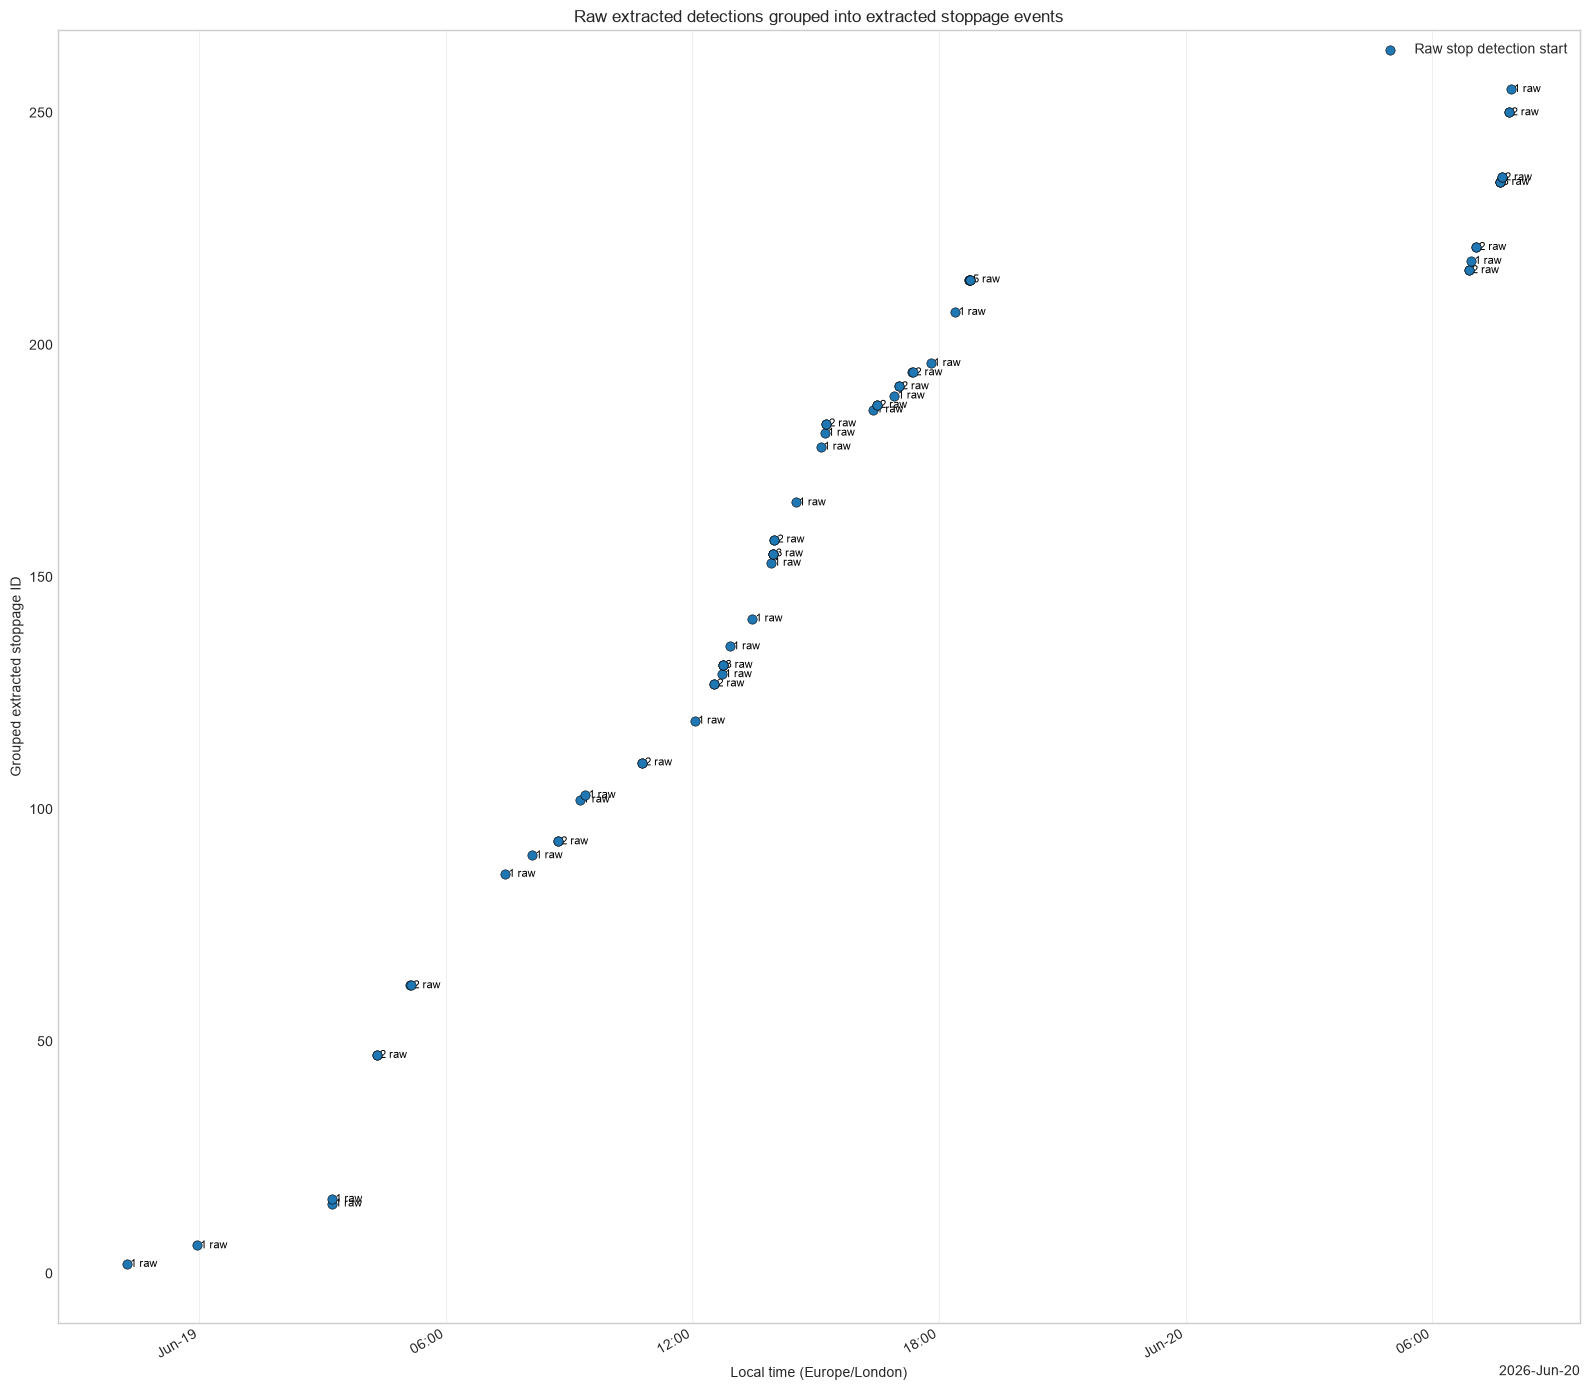

Raw extracted stop detections: 281
Grouped extracted stoppages: 257
Groups with more than one raw detection: 18
Largest raw detection count in one group: 5
Saved grouped review table to: C:\Users\TimKitchen\OneDrive\OneDrive - PurpleSector\03 Project Specific Documents\24H_INSIGHTS\24H_Insights\motion_detection\stoppage_analysis_output\grouped_extracted_stoppage_review.csv
Saved raw-to-group mapping to: C:\Users\TimKitchen\OneDrive\OneDrive - PurpleSector\03 Project Specific Documents\24H_INSIGHTS\24H_Insights\motion_detection\stoppage_analysis_output\raw_extracted_detections_mapped_to_groups.csv
Saved grouped review graph to: C:\Users\TimKitchen\OneDrive\OneDrive - PurpleSector\03 Project Specific Documents\24H_INSIGHTS\24H_Insights\motion_detection\stoppage_analysis_output\grouped_extracted_stoppage_review.png


,group_id,group_start_time,group_end_time,group_duration_seconds,raw_detections_in_group,seconds_since_previous_group,first_video_in_group,last_video_in_group
213,214,2026-06-19 18:44:26.083333333,2026-06-19 18:45:18.916666667,52.833333,5,766.416667,cortexvpu-01a-005-41884872_2026-06-19_17-44-25...,cortexvpu-01a-005-41884872_2026-06-19_17-45-04...
154,155,2026-06-19 13:57:29.166666667,2026-06-19 13:57:43.083333333,13.916667,3,80.250000,cortexvpu-01a-005-41884872_2026-06-19_12-57-29...,cortexvpu-01a-005-41884872_2026-06-19_12-57-38...
130,131,2026-06-19 12:43:53.250000000,2026-06-19 12:44:04.333333333,11.083333,3,5.750000,cortexvpu-01a-005-41884872_2026-06-19_11-43-49...,cortexvpu-01a-005-41884872_2026-06-19_11-44-00...
234,235,2026-06-20 07:38:24.166666667,2026-06-20 07:38:34.500000000,10.333333,3,17.583333,cortexvpu-01a-005-41884872_2026-06-20_06-38-24...,cortexvpu-01a-005-41884872_2026-06-20_06-38-33...
220,221,2026-06-20 07:04:07.166666667,2026-06-20 07:04:30.583333333,23.416667,2,344.916667,cortexvpu-01a-005-41884872_2026-06-20_06-04-07...,cortexvpu-01a-005-41884872_2026-06-20_06-02-14...
193,194,2026-06-19 17:21:02.750000000,2026-06-19 17:21:19.250000000,16.500000,2,476.250000,cortexvpu-01a-005-41884872_2026-06-19_16-19-22...,cortexvpu-01a-005-41884872_2026-06-19_16-21-18...
190,191,2026-06-19 17:01:17.666666667,2026-06-19 17:01:31.833333333,14.166667,2,284.916667,cortexvpu-01a-005-41884872_2026-06-19_16-00-08...,cortexvpu-01a-005-41884872_2026-06-19_16-01-27...
186,187,2026-06-19 16:29:31.500000000,2026-06-19 16:29:45.250000000,13.750000,2,319.916667,cortexvpu-01a-005-41884872_2026-06-19_15-29-29...,cortexvpu-01a-005-41884872_2026-06-19_15-28-03...
235,236,2026-06-20 07:41:56.166666667,2026-06-20 07:42:09.416666667,13.250000,2,201.666667,cortexvpu-01a-005-41884872_2026-06-20_06-41-56...,cortexvpu-01a-005-41884872_2026-06-20_06-42-05...
182,183,2026-06-19 15:15:06.166666667,2026-06-19 15:15:18.666666667,12.500000,2,19.250000,cortexvpu-01a-005-41884872_2026-06-19_14-15-05...,cortexvpu-01a-005-41884872_2026-06-19_14-15-16...


,group_id,raw_detection_number_in_group,raw_video_name,raw_stop_start_time,raw_stop_end_time,raw_interval_seconds,seconds_from_group_start,group_start_time,group_end_time,group_duration_seconds,raw_detections_in_group
1,2,1,cortexvpu-01a-005-41884872_2026-06-18_21-14-05...,2026-06-18 22:14:30.294444444,2026-06-18 22:14:51.593333333,21.298888,0.000000,2026-06-18 22:14:30.294444444,2026-06-18 22:14:51.593333333,21.298889,1
5,6,1,cortexvpu-01a-005-41884872_2026-06-18_22-56-41...,2026-06-18 23:56:53.727777778,2026-06-18 23:57:11.611111111,17.883333,0.000000,2026-06-18 23:56:53.727777778,2026-06-18 23:57:11.611111111,17.883333,1
14,15,1,cortexvpu-01a-005-41884872_2026-06-19_02-12-45...,2026-06-19 03:13:30.594444444,2026-06-19 03:13:51.506666666,20.912222,0.000000,2026-06-19 03:13:30.594444444,2026-06-19 03:13:51.506666666,20.912222,1
15,16,1,cortexvpu-01a-005-41884872_2026-06-19_02-13-56...,2026-06-19 03:13:57.063333333,2026-06-19 03:14:13.980000000,16.916666,0.000000,2026-06-19 03:13:57.063333333,2026-06-19 03:14:13.980000000,16.916667,1
46,47,1,cortexvpu-01a-005-41884872_2026-06-19_03-19-17...,2026-06-19 04:19:19.062222222,2026-06-19 04:19:22.477777778,3.415555,0.000000,2026-06-19 04:19:19.062222222,2026-06-19 04:19:28.475555556,9.413333,2
...,...,...,...,...,...,...,...,...,...,...,...
257,236,1,cortexvpu-01a-005-41884872_2026-06-20_06-41-56...,2026-06-20 07:41:56.166666667,2026-06-20 07:42:05.250000000,9.083333,0.000000,2026-06-20 07:41:56.166666667,2026-06-20 07:42:09.416666667,13.250000,2
258,236,2,cortexvpu-01a-005-41884872_2026-06-20_06-42-05...,2026-06-20 07:42:05.166666667,2026-06-20 07:42:09.416666667,4.250000,9.000000,2026-06-20 07:41:56.166666667,2026-06-20 07:42:09.416666667,13.250000,2
272,250,1,cortexvpu-01a-005-41884872_2026-06-20_06-51-57...,2026-06-20 07:51:57.166666667,2026-06-20 07:52:04.166666667,7.000000,0.000000,2026-06-20 07:51:57.166666667,2026-06-20 07:52:04.166666667,7.000000,2
273,250,2,cortexvpu-01a-005-41884872_2026-06-20_06-51-54...,2026-06-20 07:51:57.250000000,2026-06-20 07:51:59.083333333,1.833333,0.083333,2026-06-20 07:51:57.166666667,2026-06-20 07:52:04.166666667,7.000000,2


In [66]:
# Choose how many grouped stoppages to show in the review plot.
# The plot focuses on groups with the most raw detections, because those are the easiest places to validate grouping.
GROUPING_REVIEW_MAX_GROUPS_TO_PLOT = 40

# Build a clear grouped summary table.
grouped_extracted_review_df = extracted_stops_df.copy()
grouped_extracted_review_df["group_duration_seconds"] = (
    grouped_extracted_review_df["stop_end_time"] - grouped_extracted_review_df["stop_time"]
).dt.total_seconds()

# Calculate the time gap from the previous grouped stoppage.
grouped_extracted_review_df["seconds_since_previous_group"] = (
    grouped_extracted_review_df["stop_time"] - grouped_extracted_review_df["stop_end_time"].shift(1)
).dt.total_seconds()

# Rename columns for the review output so the table reads naturally.
grouped_extracted_review_df = grouped_extracted_review_df.rename(columns={
    "extracted_stop_id": "group_id",
    "stop_time": "group_start_time",
    "stop_end_time": "group_end_time",
    "source_detection_count": "raw_detections_in_group",
    "source_first_video_name": "first_video_in_group",
    "source_last_video_name": "last_video_in_group",
})

# Keep the columns that matter for reviewing grouping.
grouped_extracted_review_columns = [
    "group_id",
    "group_start_time",
    "group_end_time",
    "group_duration_seconds",
    "raw_detections_in_group",
    "seconds_since_previous_group",
    "first_video_in_group",
    "last_video_in_group",
]
grouped_extracted_review_df = grouped_extracted_review_df[grouped_extracted_review_columns].copy()

# Map every raw stop detection back to the grouped stoppage that contains it.
raw_to_group_rows = []
for group_row in grouped_extracted_review_df.itertuples(index=False):
    raw_rows_in_group_df = raw_extracted_stop_intervals_df[
        (raw_extracted_stop_intervals_df["stop_time"] >= group_row.group_start_time)
        & (raw_extracted_stop_intervals_df["stop_time"] <= group_row.group_end_time)
    ].copy()

    raw_rows_in_group_df = raw_rows_in_group_df.sort_values("stop_time").reset_index(drop=True)

    for raw_index, raw_row in enumerate(raw_rows_in_group_df.itertuples(index=False), start=1):
        raw_interval_seconds = (raw_row.stop_end_time - raw_row.stop_time).total_seconds()
        seconds_from_group_start = (raw_row.stop_time - group_row.group_start_time).total_seconds()

        raw_to_group_rows.append({
            "group_id": group_row.group_id,
            "raw_detection_number_in_group": raw_index,
            "raw_video_name": raw_row.video_name,
            "raw_stop_start_time": raw_row.stop_time,
            "raw_stop_end_time": raw_row.stop_end_time,
            "raw_interval_seconds": raw_interval_seconds,
            "seconds_from_group_start": seconds_from_group_start,
            "group_start_time": group_row.group_start_time,
            "group_end_time": group_row.group_end_time,
            "group_duration_seconds": group_row.group_duration_seconds,
            "raw_detections_in_group": group_row.raw_detections_in_group,
        })

raw_to_group_review_df = pd.DataFrame(raw_to_group_rows)

# Save the review tables so they can be opened directly in Excel.
grouped_extracted_review_path = output_dir / "grouped_extracted_stoppage_review.csv"
raw_to_group_review_path = output_dir / "raw_extracted_detections_mapped_to_groups.csv"
grouped_extracted_review_df.to_csv(grouped_extracted_review_path, index=False)
raw_to_group_review_df.to_csv(raw_to_group_review_path, index=False)

# Plot the groups with the most raw detections.
# Each orange line is one grouped stoppage. Each blue dot is one raw stop detection inside that group.
groups_to_plot_df = (
    grouped_extracted_review_df
    .sort_values(["raw_detections_in_group", "group_duration_seconds"], ascending=False)
    .head(GROUPING_REVIEW_MAX_GROUPS_TO_PLOT)
    .sort_values("group_start_time")
    .copy()
)

raw_to_group_plot_df = raw_to_group_review_df[
    raw_to_group_review_df["group_id"].isin(groups_to_plot_df["group_id"])
].copy()

plot_height = max(6, min(18, len(groups_to_plot_df) * 0.35))
fig, ax = plt.subplots(figsize=(16, plot_height))

for group_row in groups_to_plot_df.itertuples(index=False):
    ax.hlines(
        y=group_row.group_id,
        xmin=group_row.group_start_time,
        xmax=group_row.group_end_time,
        color="tab:orange",
        linewidth=5,
        alpha=0.8,
    )

    ax.text(
        group_row.group_end_time,
        group_row.group_id,
        f" {group_row.raw_detections_in_group} raw",
        va="center",
        fontsize=8,
        color="black",
    )

if not raw_to_group_plot_df.empty:
    ax.scatter(
        raw_to_group_plot_df["raw_stop_start_time"],
        raw_to_group_plot_df["group_id"],
        color="tab:blue",
        edgecolors="black",
        linewidths=0.4,
        s=45,
        zorder=5,
        label="Raw stop detection start",
    )

ax.set_title("Raw extracted detections grouped into extracted stoppage events")
ax.set_xlabel(f"Local time ({LOCAL_TIMEZONE})")
ax.set_ylabel("Grouped extracted stoppage ID")
ax.grid(True, axis="x", alpha=0.3)
ax.grid(False, axis="y")
ax.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=6, maxticks=10))
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))

if not raw_to_group_plot_df.empty:
    ax.legend(loc="upper right")

fig.autofmt_xdate()
fig.tight_layout()

grouped_extracted_review_plot_path = output_dir / "grouped_extracted_stoppage_review.png"
fig.savefig(grouped_extracted_review_plot_path, dpi=180)
plt.show()

print(f"Raw extracted stop detections: {len(raw_extracted_stop_intervals_df)}")
print(f"Grouped extracted stoppages: {len(grouped_extracted_review_df)}")
print(f"Groups with more than one raw detection: {(grouped_extracted_review_df['raw_detections_in_group'] > 1).sum()}")
print(f"Largest raw detection count in one group: {grouped_extracted_review_df['raw_detections_in_group'].max()}")
print(f"Saved grouped review table to: {grouped_extracted_review_path}")
print(f"Saved raw-to-group mapping to: {raw_to_group_review_path}")
print(f"Saved grouped review graph to: {grouped_extracted_review_plot_path}")

# Show the grouped events with the most raw detections first.
display(grouped_extracted_review_df.sort_values(
    ["raw_detections_in_group", "group_duration_seconds"],
    ascending=False,
).head(20))

# Show the raw detection mapping for the largest groups.
display(raw_to_group_plot_df.sort_values(["group_id", "raw_detection_number_in_group"]).head(80))


## 4. Load Harford Stoppages

Load the edited Harford workbook and treat the Excel `Time` column as local/site time.


In [67]:
# Read the workbook without headers because the report title rows appear above the table.
# If this fails with AssertionError, pandas/xlrd cannot parse that .xls file.
# That is a workbook-format issue, not an open-file issue.
harford_raw_workbook_df = read_harford_workbook(harford_extract_path)

# Promote the real table header row.
harford_header_row = find_harford_header_row(harford_raw_workbook_df)
harford_raw_df = promote_header_row(harford_raw_workbook_df, harford_header_row)

# Harford Excel timestamps are local/site time and do not contain timezone metadata.
harford_raw_df["harford_original_time"] = pd.to_datetime(harford_raw_df["Time"], errors="coerce", dayfirst=True)

# Apply the configured offset so all later comparisons use the adjusted Harford time.
harford_raw_df["harford_time"] = harford_raw_df["harford_original_time"] + HARFORD_TIME_OFFSET

# Keep only rows that have a valid stop timestamp.
harford_stops_df = harford_raw_df.dropna(subset=["harford_time"]).copy()
harford_stops_df = harford_stops_df.sort_values("harford_time").reset_index(drop=True)
harford_stops_df["harford_stop_id"] = np.arange(1, len(harford_stops_df) + 1)

# Convert the Harford duration column into minutes.
# Different saved versions name the duration column differently:
# - Time2 in the edited .xls file
# - Time.1 when pandas has renamed a duplicate Time header
harford_duration_column = None
for candidate_column in ["Time2", "Time.1"]:
    if candidate_column in harford_stops_df.columns:
        harford_duration_column = candidate_column
        break

if harford_duration_column is None:
    harford_stops_df["harford_duration_minutes"] = np.nan
else:
    harford_duration_seconds = pd.to_timedelta(
        harford_stops_df[harford_duration_column].astype(str),
        errors="coerce",
    ).dt.total_seconds()
    harford_stops_df["harford_duration_minutes"] = harford_duration_seconds / 60

print(f"Harford stops loaded: {len(harford_stops_df)}")
print(f"Harford duration column: {harford_duration_column}")
print(f"Harford time offset applied: {HARFORD_TIME_OFFSET_LABEL}")
print(f"Harford first adjusted stop: {harford_stops_df['harford_time'].min()}")
print(f"Harford last adjusted stop:  {harford_stops_df['harford_time'].max()}")

display(harford_stops_df.head())


Harford stops loaded: 192
Harford duration column: Time.1
Harford time offset applied: 0 minutes
Harford first adjusted stop: 2026-06-18 08:30:26.038000
Harford last adjusted stop:  2026-06-21 09:43:05.069000


,Time,Period,Type,Operator,Time type,Time.1,Group,Reason 1,Reason 2,Reason 3,Reason 4,Product,Batch,Bulk,Order,harford_original_time,harford_time,harford_stop_id,harford_duration_minutes
0,2026-06-18 08:30:26.038000,08:30:26 - 08:30:56,DB,Dagmara Smialek,Planned stops,0:00:30,NaN,Capex and commisioning,Material Issue,NaN,NaN,788367 JW BLACK 12YO 0.05L 40% 16x12 Travel R...,L6168CL002,NaN,12580725,2026-06-18 08:30:26.038,2026-06-18 08:30:26.038,1,0.500000
1,2026-06-18 08:36:03.483000,08:36:03 - 08:36:30,DB,Dagmara Smialek,Planned stops,0:00:27,NaN,Capex and commisioning,Material Issue,NaN,NaN,788367 JW BLACK 12YO 0.05L 40% 16x12 Travel R...,L6168CL002,NaN,12580725,2026-06-18 08:36:03.483,2026-06-18 08:36:03.483,2,0.450000
2,2026-06-18 08:37:07.973000,08:37:07 - 08:40:03,DB,Dagmara Smialek,Planned stops,0:02:56,NaN,Capex and commisioning,Material Issue,NaN,NaN,788367 JW BLACK 12YO 0.05L 40% 16x12 Travel R...,L6168CL002,NaN,12580725,2026-06-18 08:37:07.973,2026-06-18 08:37:07.973,3,2.933333
3,2026-06-18 09:19:24.616000,09:19:24 - 09:19:41,DB,Dagmara Smialek,Planned stops,0:00:16,NaN,Capex and commisioning,Material Issue,NaN,NaN,788367 JW BLACK 12YO 0.05L 40% 16x12 Travel R...,L6168CL002,NaN,12580725,2026-06-18 09:19:24.616,2026-06-18 09:19:24.616,4,0.266667
4,2026-06-18 09:48:23.176000,09:48:23 - 09:52:19,DB,Jean Blackwood,Planned stops,0:03:56,NaN,Capex and commisioning,Commisioning New machine/parts,NaN,NaN,788367 JW BLACK 12YO 0.05L 40% 16x12 Travel R...,L6168CL002,NaN,12580725,2026-06-18 09:48:23.176,2026-06-18 09:48:23.176,5,3.933333


## 4A. Explicit Grouped Extracted vs Harford Analysis

This section compares the grouped extracted stoppages directly against the Harford stoppages.

It uses:

- grouped extracted stoppage start and end times from Chapter 3
- adjusted Harford stop start times from Chapter 4
- Harford stop durations from the Harford duration column

The aim is to make the relationship between the two records obvious before the later summary comparisons.


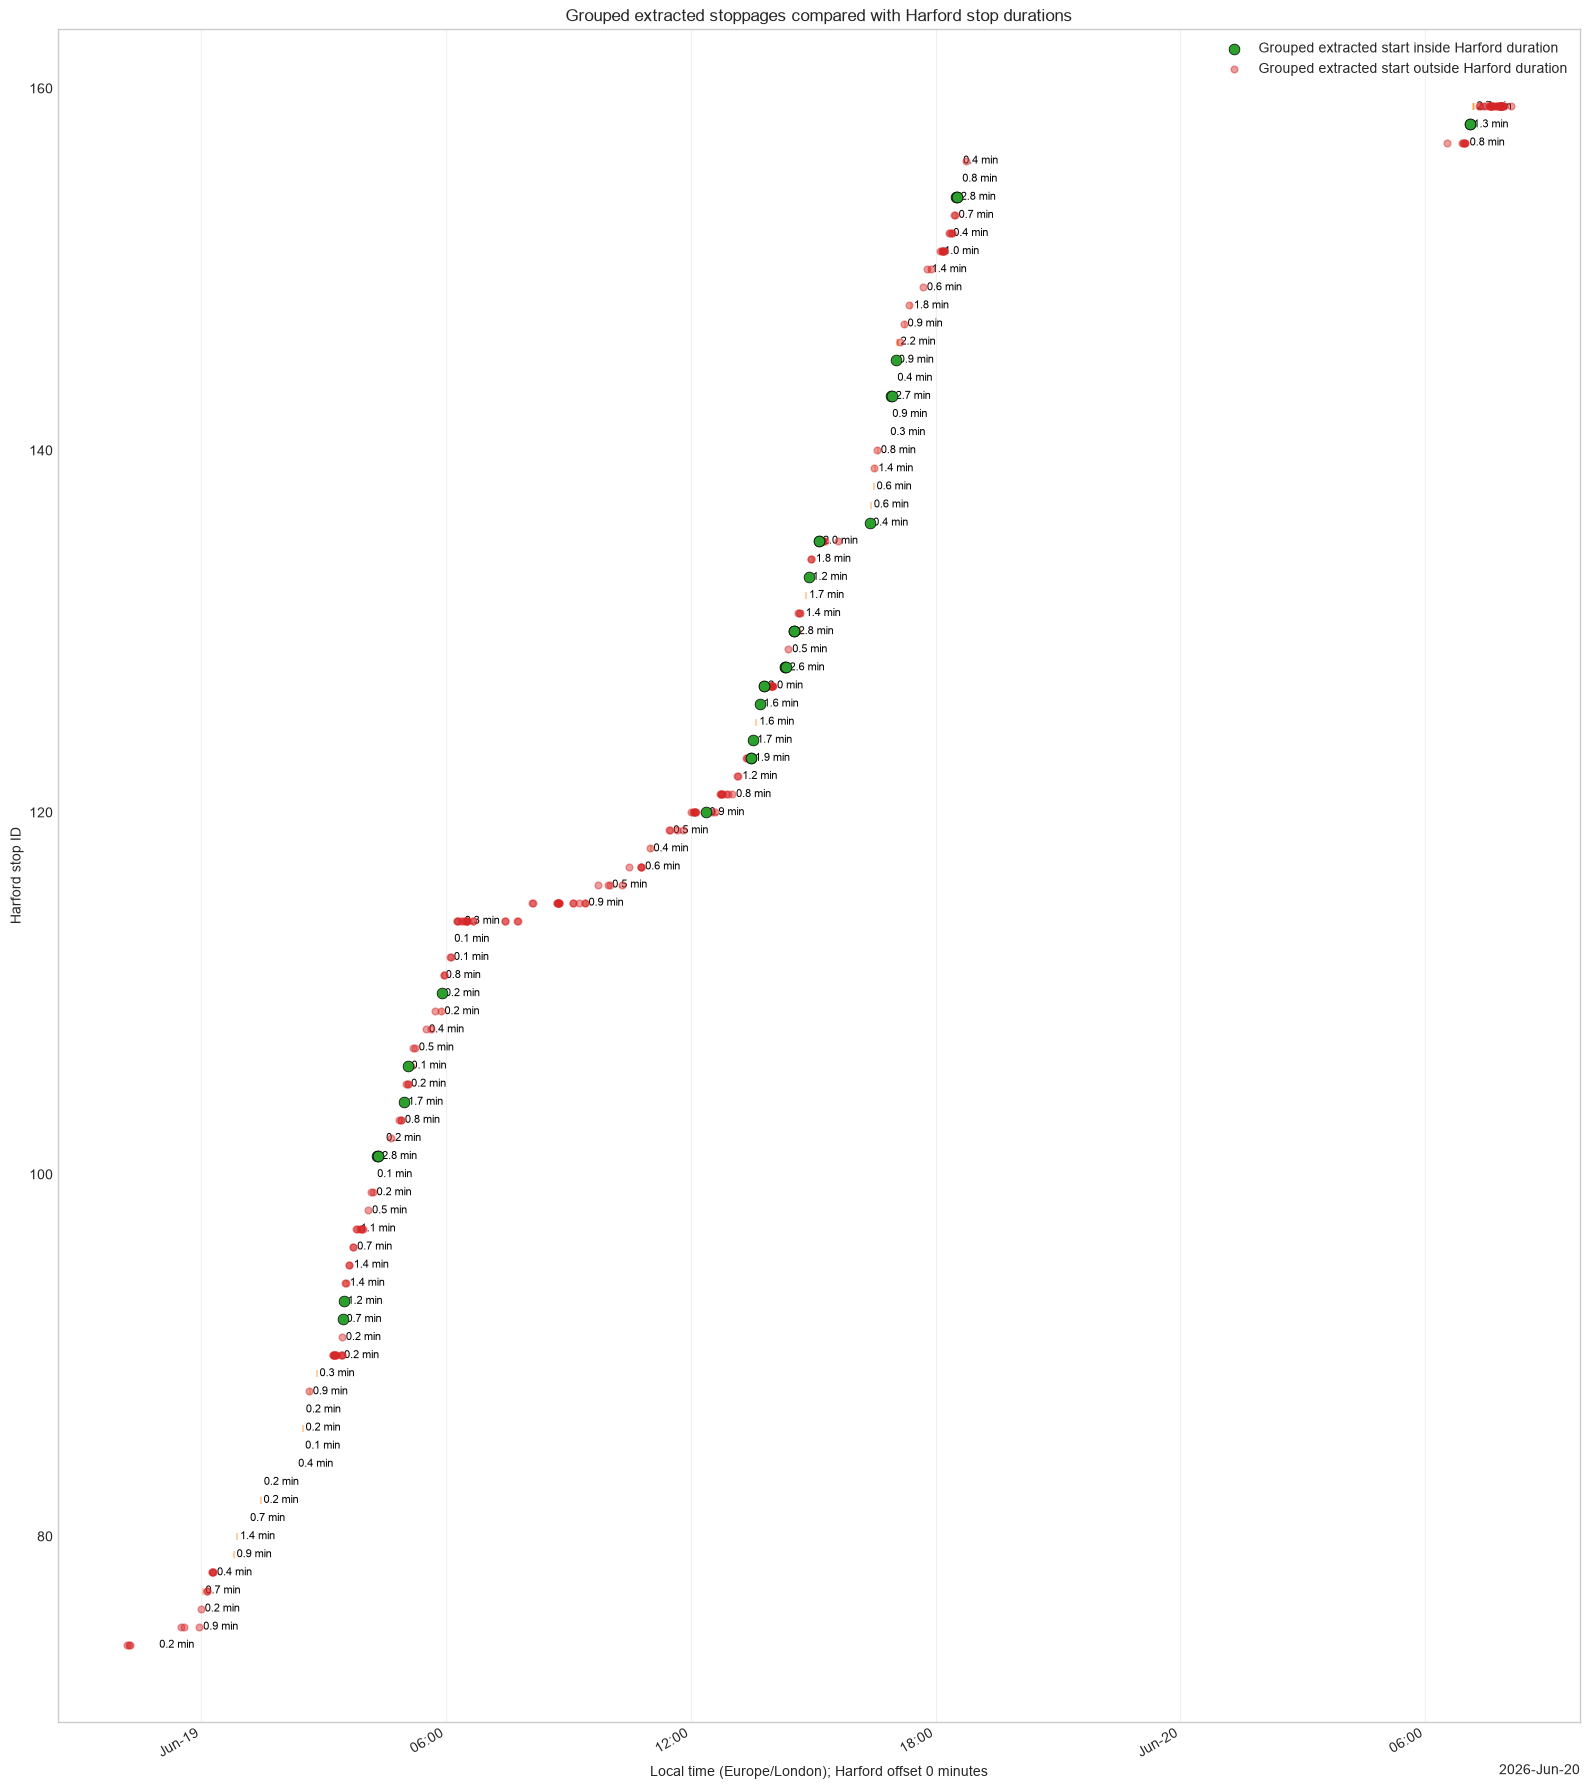

Grouped-vs-Harford shared window: 2026-06-18 22:11:06.834444444 to 2026-06-20 08:05:57.833333333
Grouped extracted stoppages in window: 257
Harford stoppages in window: 86
Grouped starts inside Harford duration: 33
Grouped intervals overlapping Harford duration: 34
Harford stops with grouped start inside duration: 20
Harford stops with grouped interval overlap: 21
Saved grouped-to-Harford table to: C:\Users\TimKitchen\OneDrive\OneDrive - PurpleSector\03 Project Specific Documents\24H_INSIGHTS\24H_Insights\motion_detection\stoppage_analysis_output\grouped_extracted_stoppages_vs_harford.csv
Saved Harford-to-grouped table to: C:\Users\TimKitchen\OneDrive\OneDrive - PurpleSector\03 Project Specific Documents\24H_INSIGHTS\24H_Insights\motion_detection\stoppage_analysis_output\harford_stoppages_vs_grouped_extracted.csv
Saved grouped-vs-Harford summary to: C:\Users\TimKitchen\OneDrive\OneDrive - PurpleSector\03 Project Specific Documents\24H_INSIGHTS\24H_Insights\motion_detection\stoppage_ana

,metric,value
0,harford_time_offset,0 minutes
1,shared_window_start,2026-06-18 22:11:06.834444444
2,shared_window_end,2026-06-20 08:05:57.833333333
3,grouped_extracted_stoppages_in_window,257
4,harford_stoppages_in_window,86
5,grouped_starts_inside_harford_duration,33
6,grouped_intervals_overlapping_harford_duration,34
7,harford_stoppages_with_grouped_start_inside_du...,20
8,harford_stoppages_with_grouped_interval_overlap,21
9,mean_seconds_to_nearest_harford_start_from_gro...,731.837415


,grouped_stop_id,grouped_stop_start_time,grouped_stop_end_time,grouped_stop_duration_seconds,raw_detections_in_group,first_video_in_group,last_video_in_group,nearest_harford_stop_id,nearest_harford_stop_start_time,nearest_harford_stop_end_time,signed_seconds_from_nearest_harford_start,absolute_seconds_from_nearest_harford_start,starts_inside_harford_duration,containing_harford_stop_id,containing_harford_stop_start_time,containing_harford_stop_end_time,seconds_after_containing_harford_start,seconds_before_containing_harford_end,overlaps_harford_duration,best_overlap_harford_stop_id,best_overlap_seconds
161,162,2026-06-19 14:18:22.166666667,2026-06-19 14:18:28.583333333,6.416667,1,cortexvpu-01a-005-41884872_2026-06-19_13-18-22...,cortexvpu-01a-005-41884872_2026-06-19_13-18-22...,128,2026-06-19 14:18:22.154,2026-06-19 14:20:56.154,0.012667,0.012667,True,128,2026-06-19 14:18:22.154,2026-06-19 14:20:56.154,0.012667,153.987333,True,128,6.416666
141,142,2026-06-19 13:28:05.166666667,2026-06-19 13:28:08.166666667,3.000000,1,cortexvpu-01a-005-41884872_2026-06-19_12-28-05...,cortexvpu-01a-005-41884872_2026-06-19_12-28-05...,123,2026-06-19 13:28:04.968,2026-06-19 13:29:55.968,0.198667,0.198667,True,123,2026-06-19 13:28:04.968,2026-06-19 13:29:55.968,0.198667,110.801333,True,123,3.000000
145,146,2026-06-19 13:31:35.166666667,2026-06-19 13:31:37.916666667,2.750000,1,cortexvpu-01a-005-41884872_2026-06-19_12-31-35...,cortexvpu-01a-005-41884872_2026-06-19_12-31-35...,124,2026-06-19 13:31:32.355,2026-06-19 13:33:15.355,2.811667,2.811667,True,124,2026-06-19 13:31:32.355,2026-06-19 13:33:15.355,2.811667,100.188333,True,124,2.750000
26,27,2026-06-19 03:28:48.061111111,2026-06-19 03:28:49.092222222,1.031111,1,cortexvpu-01a-005-41884872_2026-06-19_02-28-45...,cortexvpu-01a-005-41884872_2026-06-19_02-28-45...,92,2026-06-19 03:28:41.976,2026-06-19 03:29:20.976,6.085111,6.085111,True,92,2026-06-19 03:28:41.976,2026-06-19 03:29:20.976,6.085111,32.914888,True,92,1.031111
149,150,2026-06-19 13:47:14.166666667,2026-06-19 13:47:15.416666667,1.250000,1,cortexvpu-01a-005-41884872_2026-06-19_12-47-14...,cortexvpu-01a-005-41884872_2026-06-19_12-47-14...,127,2026-06-19 13:47:20.369,2026-06-19 13:49:18.369,-6.202333,6.202333,False,<NA>,NaT,NaT,NaN,NaN,False,<NA>,0.000000
59,60,2026-06-19 05:04:51.062222222,2026-06-19 05:04:55.895555556,4.833333,1,cortexvpu-01a-005-41884872_2026-06-19_04-04-49...,cortexvpu-01a-005-41884872_2026-06-19_04-04-49...,106,2026-06-19 05:04:44.454,2026-06-19 05:04:53.454,6.608222,6.608222,True,106,2026-06-19 05:04:44.454,2026-06-19 05:04:53.454,6.608222,2.391777,True,106,2.391777
42,43,2026-06-19 04:13:16.706666667,2026-06-19 04:13:25.954444444,9.247778,1,cortexvpu-01a-005-41884872_2026-06-19_03-13-14...,cortexvpu-01a-005-41884872_2026-06-19_03-13-14...,99,2026-06-19 04:13:23.995,2026-06-19 04:13:33.995,-7.288333,7.288333,False,<NA>,NaT,NaT,NaN,NaN,True,99,1.959444
144,145,2026-06-19 13:31:24.166666667,2026-06-19 13:31:32.333333333,8.166667,1,cortexvpu-01a-005-41884872_2026-06-19_12-31-23...,cortexvpu-01a-005-41884872_2026-06-19_12-31-23...,124,2026-06-19 13:31:32.355,2026-06-19 13:33:15.355,-8.188333,8.188333,False,<NA>,NaT,NaT,NaN,NaN,False,<NA>,0.000000
221,222,2026-06-20 07:05:25.166666667,2026-06-20 07:05:27.416666667,2.250000,1,cortexvpu-01a-005-41884872_2026-06-20_06-05-25...,cortexvpu-01a-005-41884872_2026-06-20_06-05-25...,158,2026-06-20 07:05:16.006,2026-06-20 07:06:36.006,9.160667,9.160667,True,158,2026-06-20 07:05:16.006,2026-06-20 07:06:36.006,9.160667,70.839333,True,158,2.250000
68,69,2026-06-19 05:54:04.062222222,2026-06-19 05:54:05.512222222,1.450000,1,cortexvpu-01a-005-41884872_2026-06-19_04-54-02...,cortexvpu-01a-005-41884872_2026-06-19_04-54-02...,110,2026-06-19 05:53:54.107,2026-06-19 05:54:04.107,9.955222,9.955222,True,110,2026-06-19 05:53:54.107,2026-06-19 05:54:04.107,9.955222,0.044777,True,110,0.044777


,harford_stop_id,harford_stop_start_time,harford_stop_end_time,harford_duration_seconds,harford_duration_minutes,grouped_starts_inside_harford_duration,grouped_intervals_overlapping_harford_duration,nearest_grouped_stop_id,nearest_grouped_stop_start_time,signed_seconds_from_harford_start_to_nearest_grouped_start,absolute_seconds_from_harford_start_to_nearest_grouped_start
54,128,2026-06-19 14:18:22.154,2026-06-19 14:20:56.154,154.0,2.566667,3,3,162,2026-06-19 14:18:22.166666667,0.012667,0.012667
49,123,2026-06-19 13:28:04.968,2026-06-19 13:29:55.968,111.0,1.850000,2,2,142,2026-06-19 13:28:05.166666667,0.198667,0.198667
50,124,2026-06-19 13:31:32.355,2026-06-19 13:33:15.355,103.0,1.716667,1,1,146,2026-06-19 13:31:35.166666667,2.811667,2.811667
18,92,2026-06-19 03:28:41.976,2026-06-19 03:29:20.976,39.0,0.650000,1,1,27,2026-06-19 03:28:48.061111111,6.085111,6.085111
53,127,2026-06-19 13:47:20.369,2026-06-19 13:49:18.369,118.0,1.966667,2,2,150,2026-06-19 13:47:14.166666667,-6.202333,6.202333
32,106,2026-06-19 05:04:44.454,2026-06-19 05:04:53.454,9.0,0.150000,1,1,60,2026-06-19 05:04:51.062222222,6.608222,6.608222
25,99,2026-06-19 04:13:23.995,2026-06-19 04:13:33.995,10.0,0.166667,0,1,43,2026-06-19 04:13:16.706666667,-7.288333,7.288333
84,158,2026-06-20 07:05:16.006,2026-06-20 07:06:36.006,80.0,1.333333,2,2,222,2026-06-20 07:05:25.166666667,9.160667,9.160667
36,110,2026-06-19 05:53:54.107,2026-06-19 05:54:04.107,10.0,0.166667,1,1,69,2026-06-19 05:54:04.062222222,9.955222,9.955222
41,115,2026-06-19 09:24:27.415,2026-06-19 09:25:19.415,52.0,0.866667,0,0,104,2026-06-19 09:24:16.062222222,-11.352778,11.352778


In [68]:
# Build a clean grouped extracted stoppage table for direct comparison.
grouped_vs_harford_extracted_df = extracted_stops_df.copy()
grouped_vs_harford_extracted_df["grouped_stop_id"] = grouped_vs_harford_extracted_df["extracted_stop_id"]
grouped_vs_harford_extracted_df["grouped_stop_start_time"] = grouped_vs_harford_extracted_df["stop_time"]
grouped_vs_harford_extracted_df["grouped_stop_end_time"] = grouped_vs_harford_extracted_df["stop_end_time"]
grouped_vs_harford_extracted_df["grouped_stop_duration_seconds"] = (
    grouped_vs_harford_extracted_df["grouped_stop_end_time"]
    - grouped_vs_harford_extracted_df["grouped_stop_start_time"]
).dt.total_seconds()

# Build Harford stop windows from adjusted Harford time plus duration.
grouped_vs_harford_window_df = harford_stops_df.copy()
grouped_vs_harford_window_df["harford_stop_start_time"] = grouped_vs_harford_window_df["harford_time"]
grouped_vs_harford_window_df["harford_duration_seconds"] = grouped_vs_harford_window_df["harford_duration_minutes"] * 60

# Keep rows visible even if a duration is missing.
missing_or_invalid_harford_duration = (
    grouped_vs_harford_window_df["harford_duration_seconds"].isna()
    | (grouped_vs_harford_window_df["harford_duration_seconds"] <= 0)
)
grouped_vs_harford_window_df.loc[missing_or_invalid_harford_duration, "harford_duration_seconds"] = 1

grouped_vs_harford_window_df["harford_stop_end_time"] = grouped_vs_harford_window_df["harford_stop_start_time"] + pd.to_timedelta(
    grouped_vs_harford_window_df["harford_duration_seconds"],
    unit="s",
)

# Use the time range where both records exist.
grouped_harford_window_start = max(
    grouped_vs_harford_extracted_df["grouped_stop_start_time"].min(),
    grouped_vs_harford_window_df["harford_stop_start_time"].min(),
)
grouped_harford_window_end = min(
    grouped_vs_harford_extracted_df["grouped_stop_start_time"].max(),
    grouped_vs_harford_window_df["harford_stop_end_time"].max(),
)

if grouped_harford_window_start >= grouped_harford_window_end:
    raise ValueError("Grouped extracted and Harford stoppages do not share a common time window")

# Keep grouped extracted starts inside the shared window.
grouped_extracted_window_df = grouped_vs_harford_extracted_df[
    (grouped_vs_harford_extracted_df["grouped_stop_start_time"] >= grouped_harford_window_start)
    & (grouped_vs_harford_extracted_df["grouped_stop_start_time"] <= grouped_harford_window_end)
].copy()

# Keep Harford duration windows that touch the shared window.
harford_duration_window_df = grouped_vs_harford_window_df[
    (grouped_vs_harford_window_df["harford_stop_start_time"] < grouped_harford_window_end)
    & (grouped_vs_harford_window_df["harford_stop_end_time"] > grouped_harford_window_start)
].copy()

# Compare each grouped extracted stoppage to Harford.
grouped_to_harford_rows = []
for grouped_row in grouped_extracted_window_df.itertuples(index=False):
    grouped_start_time = grouped_row.grouped_stop_start_time
    grouped_end_time = grouped_row.grouped_stop_end_time

    # Find the nearest Harford stop start time.
    nearest_harford_id = pd.NA
    nearest_harford_start_time = pd.NaT
    nearest_harford_end_time = pd.NaT
    signed_seconds_from_harford_start = np.nan
    absolute_seconds_from_harford_start = np.nan

    if not harford_duration_window_df.empty:
        harford_start_deltas = (
            grouped_start_time - harford_duration_window_df["harford_stop_start_time"]
        ).dt.total_seconds()
        nearest_harford_index = harford_start_deltas.abs().idxmin()
        nearest_harford_row = harford_duration_window_df.loc[nearest_harford_index]

        nearest_harford_id = nearest_harford_row["harford_stop_id"]
        nearest_harford_start_time = nearest_harford_row["harford_stop_start_time"]
        nearest_harford_end_time = nearest_harford_row["harford_stop_end_time"]
        signed_seconds_from_harford_start = harford_start_deltas.loc[nearest_harford_index]
        absolute_seconds_from_harford_start = abs(signed_seconds_from_harford_start)

    # Check whether the grouped extracted stop starts inside a Harford duration window.
    containing_harford_df = harford_duration_window_df[
        (harford_duration_window_df["harford_stop_start_time"] <= grouped_start_time)
        & (harford_duration_window_df["harford_stop_end_time"] >= grouped_start_time)
    ].copy()

    if containing_harford_df.empty:
        inside_harford_duration = False
        containing_harford_id = pd.NA
        containing_harford_start_time = pd.NaT
        containing_harford_end_time = pd.NaT
        seconds_after_harford_start = np.nan
        seconds_before_harford_end = np.nan
    else:
        # Use the containing Harford stop whose start is closest to the grouped extracted start.
        containing_harford_df["seconds_after_harford_start"] = (
            grouped_start_time - containing_harford_df["harford_stop_start_time"]
        ).dt.total_seconds()
        containing_harford_row = containing_harford_df.sort_values("seconds_after_harford_start").iloc[0]

        inside_harford_duration = True
        containing_harford_id = containing_harford_row["harford_stop_id"]
        containing_harford_start_time = containing_harford_row["harford_stop_start_time"]
        containing_harford_end_time = containing_harford_row["harford_stop_end_time"]
        seconds_after_harford_start = containing_harford_row["seconds_after_harford_start"]
        seconds_before_harford_end = (
            containing_harford_end_time - grouped_start_time
        ).total_seconds()

    # Check whether the grouped extracted interval overlaps any Harford duration window.
    overlapping_harford_df = harford_duration_window_df[
        (harford_duration_window_df["harford_stop_start_time"] < grouped_end_time)
        & (harford_duration_window_df["harford_stop_end_time"] > grouped_start_time)
    ].copy()

    best_overlap_seconds = 0.0
    best_overlap_harford_id = pd.NA
    for harford_row in overlapping_harford_df.itertuples(index=False):
        overlap_start_time = max(grouped_start_time, harford_row.harford_stop_start_time)
        overlap_end_time = min(grouped_end_time, harford_row.harford_stop_end_time)
        overlap_seconds = (overlap_end_time - overlap_start_time).total_seconds()

        if overlap_seconds > best_overlap_seconds:
            best_overlap_seconds = overlap_seconds
            best_overlap_harford_id = harford_row.harford_stop_id

    grouped_to_harford_rows.append({
        "grouped_stop_id": grouped_row.grouped_stop_id,
        "grouped_stop_start_time": grouped_start_time,
        "grouped_stop_end_time": grouped_end_time,
        "grouped_stop_duration_seconds": grouped_row.grouped_stop_duration_seconds,
        "raw_detections_in_group": grouped_row.source_detection_count,
        "first_video_in_group": grouped_row.source_first_video_name,
        "last_video_in_group": grouped_row.source_last_video_name,
        "nearest_harford_stop_id": nearest_harford_id,
        "nearest_harford_stop_start_time": nearest_harford_start_time,
        "nearest_harford_stop_end_time": nearest_harford_end_time,
        "signed_seconds_from_nearest_harford_start": signed_seconds_from_harford_start,
        "absolute_seconds_from_nearest_harford_start": absolute_seconds_from_harford_start,
        "starts_inside_harford_duration": inside_harford_duration,
        "containing_harford_stop_id": containing_harford_id,
        "containing_harford_stop_start_time": containing_harford_start_time,
        "containing_harford_stop_end_time": containing_harford_end_time,
        "seconds_after_containing_harford_start": seconds_after_harford_start,
        "seconds_before_containing_harford_end": seconds_before_harford_end,
        "overlaps_harford_duration": best_overlap_seconds > 0,
        "best_overlap_harford_stop_id": best_overlap_harford_id,
        "best_overlap_seconds": best_overlap_seconds,
    })

grouped_to_harford_df = pd.DataFrame(grouped_to_harford_rows)

# Compare each Harford duration window back to grouped extracted stoppages.
harford_to_grouped_rows = []
for harford_row in harford_duration_window_df.itertuples(index=False):
    # Find grouped extracted starts inside this Harford duration window.
    starts_inside_df = grouped_extracted_window_df[
        (grouped_extracted_window_df["grouped_stop_start_time"] >= harford_row.harford_stop_start_time)
        & (grouped_extracted_window_df["grouped_stop_start_time"] <= harford_row.harford_stop_end_time)
    ].copy()

    # Find grouped extracted intervals that overlap this Harford duration window.
    overlapping_grouped_df = grouped_extracted_window_df[
        (grouped_extracted_window_df["grouped_stop_start_time"] < harford_row.harford_stop_end_time)
        & (grouped_extracted_window_df["grouped_stop_end_time"] > harford_row.harford_stop_start_time)
    ].copy()

    # Find the nearest grouped extracted start time.
    nearest_grouped_id = pd.NA
    nearest_grouped_start_time = pd.NaT
    signed_seconds_from_harford_to_grouped = np.nan
    absolute_seconds_from_harford_to_grouped = np.nan

    if not grouped_extracted_window_df.empty:
        grouped_start_deltas = (
            grouped_extracted_window_df["grouped_stop_start_time"] - harford_row.harford_stop_start_time
        ).dt.total_seconds()
        nearest_grouped_index = grouped_start_deltas.abs().idxmin()
        nearest_grouped_row = grouped_extracted_window_df.loc[nearest_grouped_index]

        nearest_grouped_id = nearest_grouped_row["grouped_stop_id"]
        nearest_grouped_start_time = nearest_grouped_row["grouped_stop_start_time"]
        signed_seconds_from_harford_to_grouped = grouped_start_deltas.loc[nearest_grouped_index]
        absolute_seconds_from_harford_to_grouped = abs(signed_seconds_from_harford_to_grouped)

    harford_to_grouped_rows.append({
        "harford_stop_id": harford_row.harford_stop_id,
        "harford_stop_start_time": harford_row.harford_stop_start_time,
        "harford_stop_end_time": harford_row.harford_stop_end_time,
        "harford_duration_seconds": harford_row.harford_duration_seconds,
        "harford_duration_minutes": harford_row.harford_duration_seconds / 60,
        "grouped_starts_inside_harford_duration": len(starts_inside_df),
        "grouped_intervals_overlapping_harford_duration": len(overlapping_grouped_df),
        "nearest_grouped_stop_id": nearest_grouped_id,
        "nearest_grouped_stop_start_time": nearest_grouped_start_time,
        "signed_seconds_from_harford_start_to_nearest_grouped_start": signed_seconds_from_harford_to_grouped,
        "absolute_seconds_from_harford_start_to_nearest_grouped_start": absolute_seconds_from_harford_to_grouped,
    })

harford_to_grouped_df = pd.DataFrame(harford_to_grouped_rows)

# Save detailed outputs.
grouped_to_harford_path = output_dir / "grouped_extracted_stoppages_vs_harford.csv"
harford_to_grouped_path = output_dir / "harford_stoppages_vs_grouped_extracted.csv"
grouped_harford_summary_path = output_dir / "grouped_extracted_vs_harford_summary.csv"
grouped_harford_plot_path = output_dir / "grouped_extracted_vs_harford_timeline.png"

grouped_to_harford_df.to_csv(grouped_to_harford_path, index=False)
harford_to_grouped_df.to_csv(harford_to_grouped_path, index=False)

# Build a compact summary of the direct grouped-vs-Harford comparison.
grouped_starts_inside_count = int(grouped_to_harford_df["starts_inside_harford_duration"].sum())
grouped_overlaps_count = int(grouped_to_harford_df["overlaps_harford_duration"].sum())
harford_with_inside_count = int((harford_to_grouped_df["grouped_starts_inside_harford_duration"] > 0).sum())
harford_with_overlap_count = int((harford_to_grouped_df["grouped_intervals_overlapping_harford_duration"] > 0).sum())

if grouped_to_harford_df.empty:
    median_nearest_harford_delta = np.nan
    mean_nearest_harford_delta = np.nan
else:
    median_nearest_harford_delta = grouped_to_harford_df["absolute_seconds_from_nearest_harford_start"].median()
    mean_nearest_harford_delta = grouped_to_harford_df["absolute_seconds_from_nearest_harford_start"].mean()

if harford_to_grouped_df.empty:
    median_nearest_grouped_delta = np.nan
    mean_nearest_grouped_delta = np.nan
else:
    median_nearest_grouped_delta = harford_to_grouped_df["absolute_seconds_from_harford_start_to_nearest_grouped_start"].median()
    mean_nearest_grouped_delta = harford_to_grouped_df["absolute_seconds_from_harford_start_to_nearest_grouped_start"].mean()

grouped_harford_summary_df = pd.DataFrame([
    ("harford_time_offset", HARFORD_TIME_OFFSET_LABEL),
    ("shared_window_start", grouped_harford_window_start),
    ("shared_window_end", grouped_harford_window_end),
    ("grouped_extracted_stoppages_in_window", len(grouped_extracted_window_df)),
    ("harford_stoppages_in_window", len(harford_duration_window_df)),
    ("grouped_starts_inside_harford_duration", grouped_starts_inside_count),
    ("grouped_intervals_overlapping_harford_duration", grouped_overlaps_count),
    ("harford_stoppages_with_grouped_start_inside_duration", harford_with_inside_count),
    ("harford_stoppages_with_grouped_interval_overlap", harford_with_overlap_count),
    ("mean_seconds_to_nearest_harford_start_from_grouped", mean_nearest_harford_delta),
    ("median_seconds_to_nearest_harford_start_from_grouped", median_nearest_harford_delta),
    ("mean_seconds_to_nearest_grouped_start_from_harford", mean_nearest_grouped_delta),
    ("median_seconds_to_nearest_grouped_start_from_harford", median_nearest_grouped_delta),
], columns=["metric", "value"])
grouped_harford_summary_df.to_csv(grouped_harford_summary_path, index=False)

# Plot Harford duration windows and grouped extracted starts together.
plot_height = max(6, min(18, len(harford_duration_window_df) * 0.28))
fig, ax = plt.subplots(figsize=(16, plot_height))

for harford_row in harford_duration_window_df.itertuples(index=False):
    ax.hlines(
        y=harford_row.harford_stop_id,
        xmin=harford_row.harford_stop_start_time,
        xmax=harford_row.harford_stop_end_time,
        color="tab:orange",
        linewidth=5,
        alpha=0.75,
    )

    ax.text(
        harford_row.harford_stop_end_time,
        harford_row.harford_stop_id,
        f" {harford_row.harford_duration_seconds / 60:.1f} min",
        va="center",
        fontsize=8,
        color="black",
    )

# Plot grouped extracted starts that land inside Harford duration windows in green.
inside_plot_df = grouped_to_harford_df[grouped_to_harford_df["starts_inside_harford_duration"]].copy()
if not inside_plot_df.empty:
    ax.scatter(
        inside_plot_df["grouped_stop_start_time"],
        inside_plot_df["containing_harford_stop_id"],
        color="tab:green",
        edgecolors="black",
        linewidths=0.5,
        s=60,
        zorder=6,
        label="Grouped extracted start inside Harford duration",
    )

# Plot grouped extracted starts outside Harford duration windows against their nearest Harford stop.
outside_plot_df = grouped_to_harford_df[~grouped_to_harford_df["starts_inside_harford_duration"]].copy()
if not outside_plot_df.empty:
    ax.scatter(
        outside_plot_df["grouped_stop_start_time"],
        outside_plot_df["nearest_harford_stop_id"],
        color="tab:red",
        alpha=0.45,
        s=24,
        zorder=4,
        label="Grouped extracted start outside Harford duration",
    )

ax.set_title("Grouped extracted stoppages compared with Harford stop durations")
ax.set_xlabel(f"Local time ({LOCAL_TIMEZONE}); Harford offset {HARFORD_TIME_OFFSET_LABEL}")
ax.set_ylabel("Harford stop ID")
ax.grid(True, axis="x", alpha=0.3)
ax.grid(False, axis="y")
ax.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=6, maxticks=10))
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
ax.legend(loc="upper right")
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(grouped_harford_plot_path, dpi=180)
plt.show()

print(f"Grouped-vs-Harford shared window: {grouped_harford_window_start} to {grouped_harford_window_end}")
print(f"Grouped extracted stoppages in window: {len(grouped_extracted_window_df)}")
print(f"Harford stoppages in window: {len(harford_duration_window_df)}")
print(f"Grouped starts inside Harford duration: {grouped_starts_inside_count}")
print(f"Grouped intervals overlapping Harford duration: {grouped_overlaps_count}")
print(f"Harford stops with grouped start inside duration: {harford_with_inside_count}")
print(f"Harford stops with grouped interval overlap: {harford_with_overlap_count}")
print(f"Saved grouped-to-Harford table to: {grouped_to_harford_path}")
print(f"Saved Harford-to-grouped table to: {harford_to_grouped_path}")
print(f"Saved grouped-vs-Harford summary to: {grouped_harford_summary_path}")
print(f"Saved grouped-vs-Harford graph to: {grouped_harford_plot_path}")

display(grouped_harford_summary_df)
display(grouped_to_harford_df.sort_values("absolute_seconds_from_nearest_harford_start").head(20))
display(harford_to_grouped_df.sort_values("absolute_seconds_from_harford_start_to_nearest_grouped_start").head(20))


## 5. Compare All Extracted Stoppages Against Harford

Match each extracted stoppage to the nearest Harford stop within `MATCH_TOLERANCE`, and also match each Harford stop back to the nearest extracted stoppage.


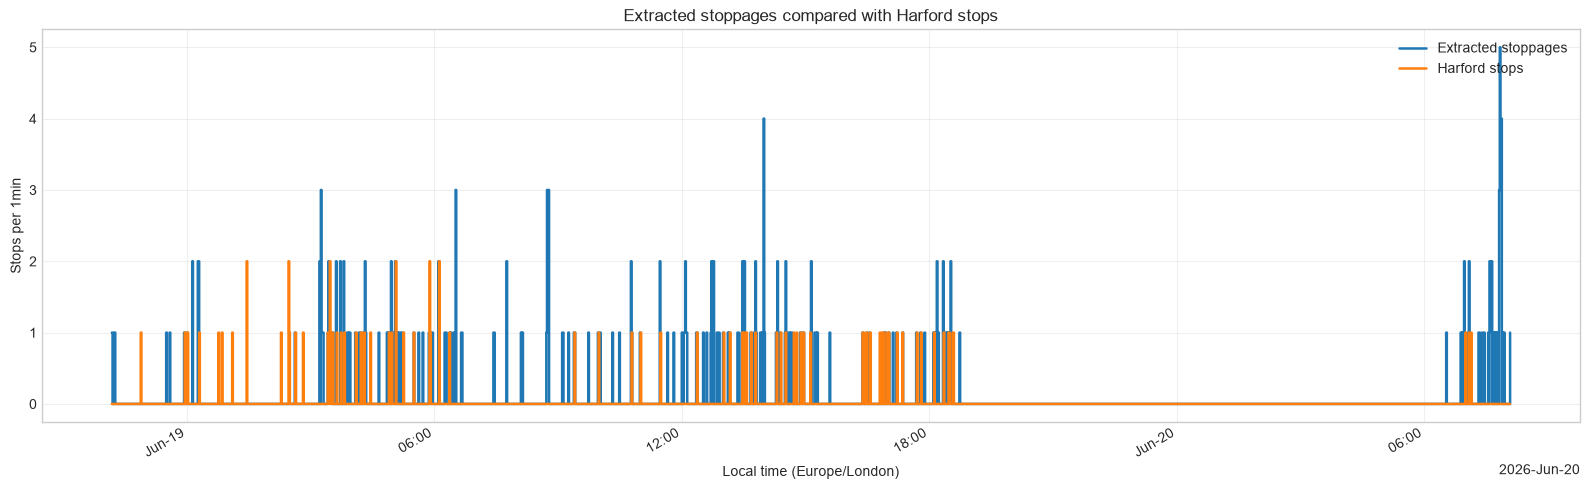

Saved extracted-to-Harford matches to: C:\Users\TimKitchen\OneDrive\OneDrive - PurpleSector\03 Project Specific Documents\24H_INSIGHTS\24H_Insights\motion_detection\stoppage_analysis_output\stop_record_extracted_stoppages_matched_to_harford.csv
Saved Harford-to-extracted matches to: C:\Users\TimKitchen\OneDrive\OneDrive - PurpleSector\03 Project Specific Documents\24H_INSIGHTS\24H_Insights\motion_detection\stoppage_analysis_output\stop_record_harford_stops_matched_to_extracted_stoppages.csv
Saved summary to: C:\Users\TimKitchen\OneDrive\OneDrive - PurpleSector\03 Project Specific Documents\24H_INSIGHTS\24H_Insights\motion_detection\stoppage_analysis_output\stop_record_comparison_summary.csv
Saved plot to: C:\Users\TimKitchen\OneDrive\OneDrive - PurpleSector\03 Project Specific Documents\24H_INSIGHTS\24H_Insights\motion_detection\stoppage_analysis_output\stop_record_time_comparison.png
Comparison window: 2026-06-18 22:11:06.834444444 to 2026-06-20 08:05:57.833333333
Extracted stoppages 

,metric,value
0,comparison_label,stop_record
1,comparison_window_start,2026-06-18 22:11:06.834444444
2,comparison_window_end,2026-06-20 08:05:57.833333333
3,match_tolerance,0 days 00:02:00
4,stop_merge_gap,0 days 00:01:00
5,local_timezone,Europe/London
6,extracted_filename_timestamps_treated_as_utc,True
7,harford_timestamps_treated_as,local/site Excel time
8,extracted_stoppage_count,257
9,harford_stop_count,86


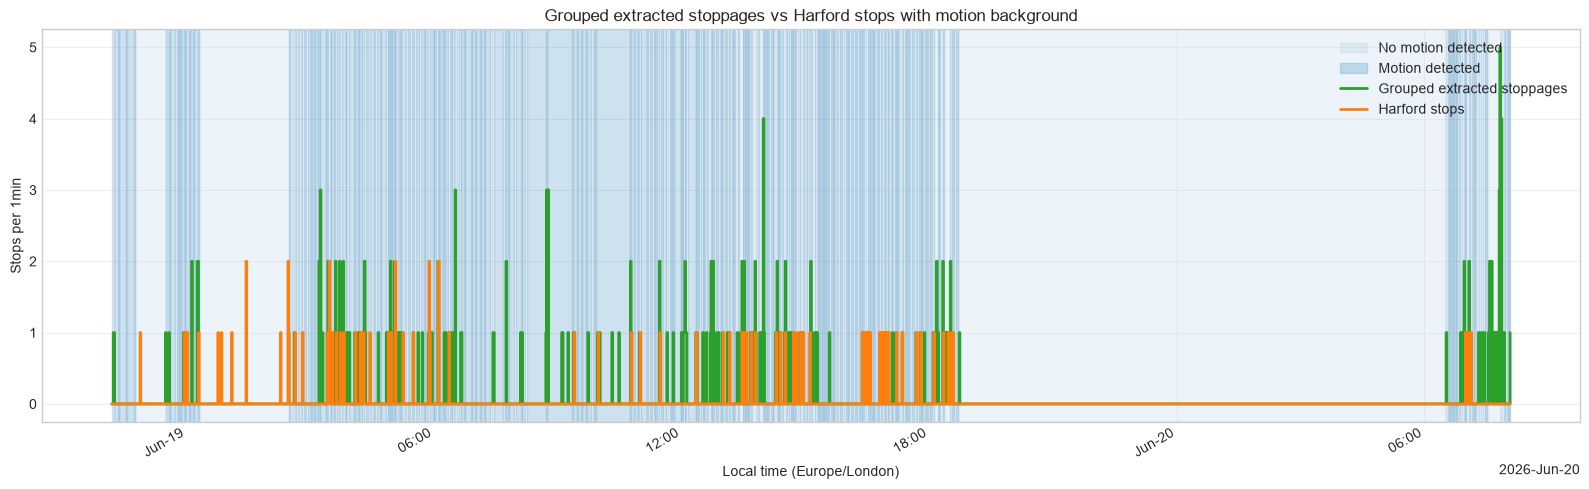

Saved grouped Chapter 5 plot to: C:\Users\TimKitchen\OneDrive\OneDrive - PurpleSector\03 Project Specific Documents\24H_INSIGHTS\24H_Insights\motion_detection\stoppage_analysis_output\stop_record_grouped_time_comparison.png
Saved grouped Chapter 5 counts to: C:\Users\TimKitchen\OneDrive\OneDrive - PurpleSector\03 Project Specific Documents\24H_INSIGHTS\24H_Insights\motion_detection\stoppage_analysis_output\stop_record_grouped_time_counts.csv
Saved grouped Chapter 5 summary to: C:\Users\TimKitchen\OneDrive\OneDrive - PurpleSector\03 Project Specific Documents\24H_INSIGHTS\24H_Insights\motion_detection\stoppage_analysis_output\stop_record_grouped_time_summary.csv


,metric,value
0,comparison_label,stop_record_grouped
1,comparison_window_start,2026-06-18 22:11:06.834444444
2,comparison_window_end,2026-06-20 08:05:57.833333333
3,time_bin,1min
4,grouped_extracted_stoppages_in_window,257
5,harford_stops_in_window,86
6,motion_rows_with_motion_detected,1019
7,time_bins_in_window,2034
8,time_bins_with_motion,799
9,time_bins_without_motion,1235


In [69]:
# Compare the full extracted stoppage record against Harford.
all_stops_comparison = compare_stops_by_time(
    extracted_stops_df,
    harford_stops_df,
    MATCH_TOLERANCE,
)

# Save the original filenames used by the previous notebook version.
all_stops_comparison["extracted_to_harford_df"].to_csv(
    output_dir / "extracted_stoppages_matched_to_harford.csv",
    index=False,
)
all_stops_comparison["harford_to_extracted_df"].to_csv(
    output_dir / "harford_stops_matched_to_extracted_stoppages.csv",
    index=False,
)

# Save the simplified output set.
all_summary_df = save_comparison_outputs(
    all_stops_comparison,
    output_prefix="stop_record",
    plot_title="Extracted stoppages compared with Harford stops",
)

print(f"Comparison window: {all_stops_comparison['window_start']} to {all_stops_comparison['window_end']}")
print(f"Extracted stoppages in window: {len(all_stops_comparison['extracted_window_df'])}")
print(f"Harford stops in window: {len(all_stops_comparison['harford_window_df'])}")
print(f"Extracted stoppages matched to Harford: {int(all_stops_comparison['extracted_to_harford_df']['matched_harford_stop'].sum())}")
print(f"Harford stops matched to extracted stoppages: {int(all_stops_comparison['harford_to_extracted_df']['matched_extracted_stop'].sum())}")

display(all_summary_df)

# Build the same Chapter 5 count graph again, but label it explicitly as the
# grouped extracted stoppage view so it is easy to compare with the original.
all_grouped_counts_df = build_stop_counts(
    all_stops_comparison["extracted_window_df"],
    all_stops_comparison["harford_window_df"],
)

# Add motion/no-motion state for the same Chapter 5 shared window.
all_motion_signal_df = processed_motion_df.copy()
all_motion_signal_df["source_filename_time"] = extract_video_datetime(all_motion_signal_df["video_name"])
all_motion_signal_df["motion_time"] = convert_extracted_timestamp_to_local_time(
    all_motion_signal_df["source_filename_time"]
)
all_motion_signal_df["motion_detected"] = all_motion_signal_df["tail_motion_ratio"].fillna(0) > 0
all_motion_signal_df = all_motion_signal_df[
    (all_motion_signal_df["motion_time"] >= all_stops_comparison["window_start"])
    & (all_motion_signal_df["motion_time"] <= all_stops_comparison["window_end"])
    & all_motion_signal_df["motion_detected"]
].copy()
all_motion_detected_counts_df = (
    all_motion_signal_df
    .set_index("motion_time")
    .resample(TIME_BIN)
    .size()
    .rename("motion_detected_count")
)

all_grouped_counts_df = pd.concat(
    [all_grouped_counts_df, all_motion_detected_counts_df],
    axis=1,
).fillna(0)

# Reindex every bin in the shared window so the motion background shows both
# motion and no-motion periods explicitly.
all_grouped_full_time_index = pd.date_range(
    start=all_stops_comparison["window_start"].floor(TIME_BIN),
    end=all_stops_comparison["window_end"].ceil(TIME_BIN),
    freq=TIME_BIN,
)
all_grouped_counts_df = all_grouped_counts_df.reindex(all_grouped_full_time_index, fill_value=0)
all_grouped_counts_df = all_grouped_counts_df[
    (all_grouped_counts_df.index >= all_stops_comparison["window_start"])
    & (all_grouped_counts_df.index <= all_stops_comparison["window_end"])
].copy()

all_grouped_counts_path = output_dir / "stop_record_grouped_time_counts.csv"
all_grouped_plot_path = output_dir / "stop_record_grouped_time_comparison.png"
all_grouped_summary_path = output_dir / "stop_record_grouped_time_summary.csv"
all_grouped_counts_df.to_csv(all_grouped_counts_path)

fig, ax = plt.subplots(figsize=(16, 5))
all_motion_state = (all_grouped_counts_df["motion_detected_count"] > 0).astype(int)

# Use the chart background to show motion vs no motion for each time bin.
ax.fill_between(
    all_grouped_counts_df.index,
    0,
    1,
    where=all_motion_state == 0,
    step="post",
    transform=ax.get_xaxis_transform(),
    color="tab:blue",
    alpha=0.08,
    label="No motion detected",
    zorder=0,
)
ax.fill_between(
    all_grouped_counts_df.index,
    0,
    1,
    where=all_motion_state == 1,
    step="post",
    transform=ax.get_xaxis_transform(),
    color="tab:blue",
    alpha=0.22,
    label="Motion detected",
    zorder=1,
)

# Plot grouped extracted stoppages per time bin.
ax.step(
    all_grouped_counts_df.index,
    all_grouped_counts_df["extracted_stoppage_count"],
    where="post",
    color="tab:green",
    linewidth=2.0,
    label="Grouped extracted stoppages",
    zorder=3,
)

# Plot Harford stops on the same axes for direct comparison.
ax.step(
    all_grouped_counts_df.index,
    all_grouped_counts_df["harford_stop_count"],
    where="post",
    color="tab:orange",
    linewidth=2.0,
    label="Harford stops",
    zorder=4,
)

ax.set_title("Grouped extracted stoppages vs Harford stops with motion background")
ax.set_xlabel(f"Local time ({LOCAL_TIMEZONE})")
ax.set_ylabel(f"Stops per {TIME_BIN}")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=6, maxticks=10))
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(all_grouped_plot_path, dpi=180)
plt.show()

# Save a small graph-specific summary for the grouped Chapter 5 view.
all_grouped_summary_df = pd.DataFrame([
    ("comparison_label", "stop_record_grouped"),
    ("comparison_window_start", all_stops_comparison["window_start"]),
    ("comparison_window_end", all_stops_comparison["window_end"]),
    ("time_bin", str(TIME_BIN)),
    ("grouped_extracted_stoppages_in_window", len(all_stops_comparison["extracted_window_df"])),
    ("harford_stops_in_window", len(all_stops_comparison["harford_window_df"])),
    ("motion_rows_with_motion_detected", len(all_motion_signal_df)),
    ("time_bins_in_window", len(all_grouped_counts_df)),
    ("time_bins_with_motion", int(all_motion_state.sum())),
    ("time_bins_without_motion", int((all_motion_state == 0).sum())),
    ("grouped_extracted_stop_bins", int((all_grouped_counts_df["extracted_stoppage_count"] > 0).sum())),
    ("harford_stop_bins", int((all_grouped_counts_df["harford_stop_count"] > 0).sum())),
    ("peak_grouped_extracted_stops_per_bin", int(all_grouped_counts_df["extracted_stoppage_count"].max())),
    ("peak_harford_stops_per_bin", int(all_grouped_counts_df["harford_stop_count"].max())),
], columns=["metric", "value"])
all_grouped_summary_df.to_csv(all_grouped_summary_path, index=False)

print(f"Saved grouped Chapter 5 plot to: {all_grouped_plot_path}")
print(f"Saved grouped Chapter 5 counts to: {all_grouped_counts_path}")
print(f"Saved grouped Chapter 5 summary to: {all_grouped_summary_path}")
display(all_grouped_summary_df)


## 6. Stop-Clips-Only Comparison

Repeat the same comparison, but only for videos that exist in `stoppage_detection/stop_clips`.


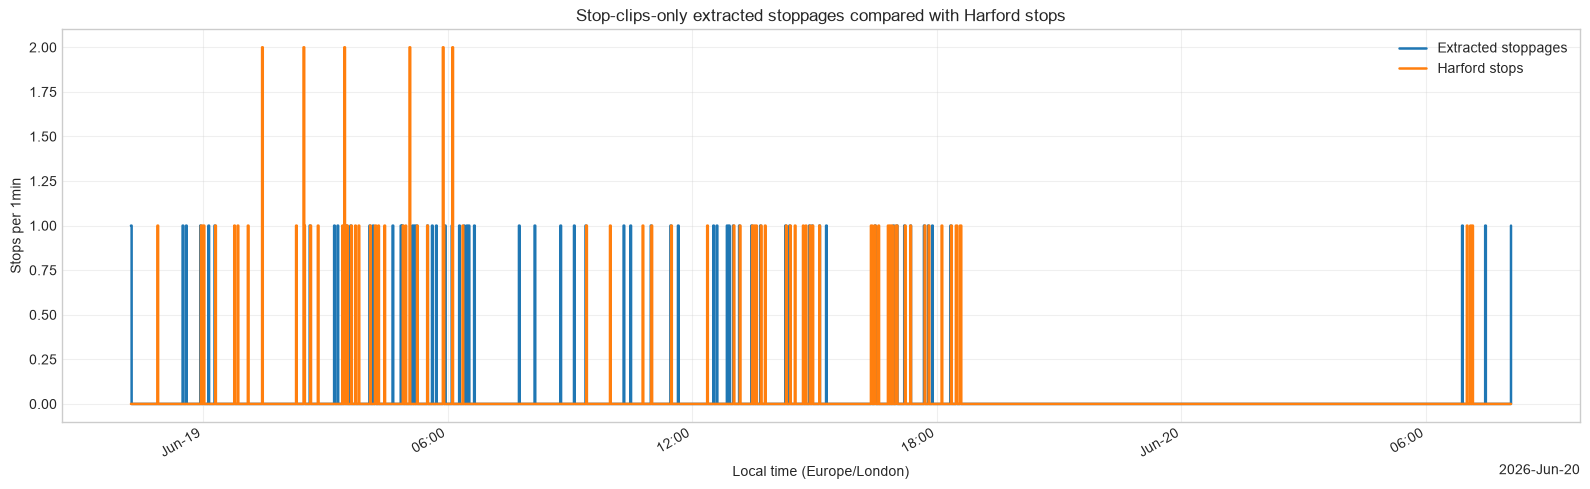

Saved extracted-to-Harford matches to: C:\Users\TimKitchen\OneDrive\OneDrive - PurpleSector\03 Project Specific Documents\24H_INSIGHTS\24H_Insights\motion_detection\stoppage_analysis_output\stop_clips_only_extracted_stoppages_matched_to_harford.csv
Saved Harford-to-extracted matches to: C:\Users\TimKitchen\OneDrive\OneDrive - PurpleSector\03 Project Specific Documents\24H_INSIGHTS\24H_Insights\motion_detection\stoppage_analysis_output\stop_clips_only_harford_stops_matched_to_extracted_stoppages.csv
Saved summary to: C:\Users\TimKitchen\OneDrive\OneDrive - PurpleSector\03 Project Specific Documents\24H_INSIGHTS\24H_Insights\motion_detection\stoppage_analysis_output\stop_clips_only_comparison_summary.csv
Saved plot to: C:\Users\TimKitchen\OneDrive\OneDrive - PurpleSector\03 Project Specific Documents\24H_INSIGHTS\24H_Insights\motion_detection\stoppage_analysis_output\stop_clips_only_time_comparison.png


C:\Users\TimKitchen\AppData\Local\Temp\ipykernel_34900\2039288097.py:109: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  stop_clip_matched_plot_counts_df = pd.concat(


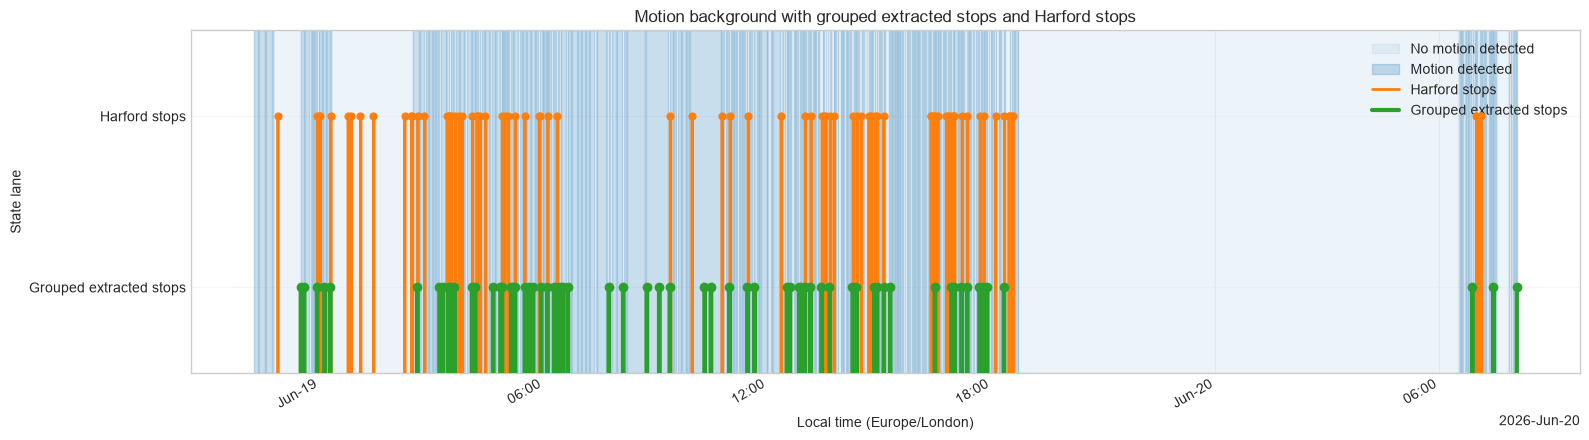

Stop clip files found: 67
Unique source videos in stop_clips: 66
Raw extracted stop intervals after stop_clips filter: 66
Grouped stop_clips-only extracted stoppages: 66
Stop_clips-only extracted stoppages matched to Harford: 31
Harford stops matched to stop_clips-only extracted stoppages: 36
Stop_clips-only average Harford-to-nearest-extracted-active delta: 441.24 seconds
Stop_clips-only Harford stops with exact extracted-active overlap: 2
Saved stop_clips-only Harford nearest extracted-active deltas to: C:\Users\TimKitchen\OneDrive\OneDrive - PurpleSector\03 Project Specific Documents\24H_INSIGHTS\24H_Insights\motion_detection\stoppage_analysis_output\stop_clips_only_harford_stops_nearest_extracted_active.csv
Saved stop_clips-only matched graph to: C:\Users\TimKitchen\OneDrive\OneDrive - PurpleSector\03 Project Specific Documents\24H_INSIGHTS\24H_Insights\motion_detection\stoppage_analysis_output\stop_clips_only_motion_harford_my_stops_time_comparison.png
Saved stop_clips-only matche

,metric,value
0,comparison_label,stop_clips_only
1,comparison_window_start,2026-06-18 22:14:30.294444444
2,comparison_window_end,2026-06-20 08:05:57.833333333
3,match_tolerance,0 days 00:02:00
4,stop_merge_gap,0 days 00:01:00
5,local_timezone,Europe/London
6,extracted_filename_timestamps_treated_as_utc,True
7,harford_timestamps_treated_as,local/site Excel time
8,extracted_stoppage_count,66
9,harford_stop_count,86


In [70]:
# Build a small index of videos represented by stop_clips files.
stop_clip_rows = []
for clip_path in sorted(stop_clips_dir.rglob("*")):
    if not clip_path.is_file():
        continue

    # Stop clips are named like original_filename_before_stop.mp4.
    clip_stem = clip_path.stem
    if clip_stem.endswith("_before_stop"):
        source_video_stem = clip_stem[: -len("_before_stop")]
    else:
        source_video_stem = clip_stem

    stop_clip_rows.append({
        "stop_clip_path": str(clip_path),
        "stop_clip_name": clip_path.name,
        "video_name": f"{source_video_stem}.ts",
    })

stop_clip_index_df = pd.DataFrame(stop_clip_rows)
if stop_clip_index_df.empty:
    raise ValueError("No files were found in stoppage_detection/stop_clips")

# Keep one row per source video.
stop_clip_video_index_df = (
    stop_clip_index_df
    .groupby("video_name", as_index=False)
    .agg(stop_clip_count=("stop_clip_name", "count"))
)
stop_clip_video_index_df.to_csv(output_dir / "stop_clips_only_video_index.csv", index=False)

# Filter the raw extracted stop rows to stop_clips videos.
stop_clip_video_names = set(stop_clip_video_index_df["video_name"])
stop_clip_raw_stops_df = raw_extracted_stops_df[
    raw_extracted_stops_df["video_name"].isin(stop_clip_video_names)
].copy()

# Group the filtered detections until motion resumes, matching Chapter 3.
stop_clip_extracted_stops_df = group_stop_intervals_until_motion_resumes(stop_clip_raw_stops_df)

# Compare stop_clips-only extracted stoppages against Harford.
stop_clip_comparison = compare_stops_by_time(
    stop_clip_extracted_stops_df,
    harford_stops_df,
    MATCH_TOLERANCE,
)

# Save the original filenames used by the previous notebook version.
stop_clip_comparison["extracted_to_harford_df"].to_csv(
    output_dir / "stop_clips_only_extracted_stoppages_matched_to_harford.csv",
    index=False,
)
stop_clip_comparison["harford_to_extracted_df"].to_csv(
    output_dir / "stop_clips_only_harford_stops_matched_to_extracted_stoppages.csv",
    index=False,
)

# Save the simplified output set.
stop_clip_summary_df = save_comparison_outputs(
    stop_clip_comparison,
    output_prefix="stop_clips_only",
    plot_title="Stop-clips-only extracted stoppages compared with Harford stops",
)

# Build a Chapter 6 graph with the three operational signals requested for review:
# motion detected, Harford stops, and my detected stops.
stop_clip_comparison_window_start = stop_clip_comparison["window_start"]
stop_clip_comparison_window_end = stop_clip_comparison["window_end"]

# Motion-detected bins come from the raw motion pipeline output.
motion_signal_df = processed_motion_df.copy()
motion_signal_df["source_filename_time"] = extract_video_datetime(motion_signal_df["video_name"])
motion_signal_df["motion_time"] = convert_extracted_timestamp_to_local_time(
    motion_signal_df["source_filename_time"]
)
motion_signal_df["motion_detected"] = motion_signal_df["tail_motion_ratio"].fillna(0) > 0
motion_signal_df = motion_signal_df[
    (motion_signal_df["motion_time"] >= stop_clip_comparison_window_start)
    & (motion_signal_df["motion_time"] <= stop_clip_comparison_window_end)
    & motion_signal_df["motion_detected"]
].copy()

motion_detected_counts_df = (
    motion_signal_df
    .set_index("motion_time")
    .resample(TIME_BIN)
    .size()
    .rename("motion_detected_count")
)

# Harford stops use the same comparison window as the stop-clips-only comparison.
stop_clip_harford_counts_df = (
    stop_clip_comparison["harford_window_df"]
    .set_index("harford_time")
    .resample(TIME_BIN)
    .size()
    .rename("harford_stop_count")
)

# Grouped extracted stops come from the grouped stop-clips-only stoppages.
grouped_extracted_stop_counts_df = (
    stop_clip_extracted_stops_df
    .set_index("stop_time")
    .resample(TIME_BIN)
    .size()
    .rename("grouped_extracted_stop_count")
)

stop_clip_matched_plot_counts_df = pd.concat(
    [motion_detected_counts_df, stop_clip_harford_counts_df, grouped_extracted_stop_counts_df],
    axis=1,
).fillna(0)

# Reindex to every time bin in the shared window so the motion background also
# shows explicit no-motion periods instead of skipping quiet gaps entirely.
full_time_index = pd.date_range(
    start=stop_clip_comparison_window_start.floor(TIME_BIN),
    end=stop_clip_comparison_window_end.ceil(TIME_BIN),
    freq=TIME_BIN,
)
stop_clip_matched_plot_counts_df = stop_clip_matched_plot_counts_df.reindex(full_time_index, fill_value=0)
stop_clip_matched_plot_counts_df = stop_clip_matched_plot_counts_df[
    (stop_clip_matched_plot_counts_df.index >= stop_clip_comparison_window_start)
    & (stop_clip_matched_plot_counts_df.index <= stop_clip_comparison_window_end)
].copy()

stop_clip_matched_plot_counts_path = output_dir / "stop_clips_only_motion_harford_my_stops_time_counts.csv"
stop_clip_matched_plot_path = output_dir / "stop_clips_only_motion_harford_my_stops_time_comparison.png"
stop_clip_matched_plot_counts_df.to_csv(stop_clip_matched_plot_counts_path)

# Plot stop signals as lanes and use the whole chart background to show whether
# motion was detected in each time bin.
fig, ax = plt.subplots(figsize=(16, 4.5))
motion_state = (stop_clip_matched_plot_counts_df["motion_detected_count"] > 0).astype(int)
harford_state = (stop_clip_matched_plot_counts_df["harford_stop_count"] > 0).astype(int)
grouped_extracted_state = (stop_clip_matched_plot_counts_df["grouped_extracted_stop_count"] > 0).astype(int)

# Fill the full chart height so motion reads as a background state rather than
# as another line on its own lane.
ax.fill_between(
    stop_clip_matched_plot_counts_df.index,
    0,
    1,
    where=motion_state == 0,
    step="post",
    transform=ax.get_xaxis_transform(),
    color="tab:blue",
    alpha=0.08,
    label="No motion detected",
    zorder=0,
)
ax.fill_between(
    stop_clip_matched_plot_counts_df.index,
    0,
    1,
    where=motion_state == 1,
    step="post",
    transform=ax.get_xaxis_transform(),
    color="tab:blue",
    alpha=0.24,
    label="Motion detected",
    zorder=1,
)
ax.step(
    stop_clip_matched_plot_counts_df.index,
    harford_state * 2,
    where="post",
    color="tab:orange",
    linewidth=2.0,
    label="Harford stops",
    zorder=3,
)
ax.step(
    stop_clip_matched_plot_counts_df.index,
    grouped_extracted_state * 1,
    where="post",
    color="tab:green",
    linewidth=3.0,
    label="Grouped extracted stops",
    zorder=4,
)

# Add markers only where a stop state is active, so the two stop series are easy to compare.
harford_bins_df = stop_clip_matched_plot_counts_df[harford_state == 1]
grouped_extracted_bins_df = stop_clip_matched_plot_counts_df[grouped_extracted_state == 1]
ax.scatter(harford_bins_df.index, [2] * len(harford_bins_df), color="tab:orange", s=24, zorder=6)
ax.scatter(grouped_extracted_bins_df.index, [1] * len(grouped_extracted_bins_df), color="tab:green", s=36, zorder=7)

ax.set_title("Motion background with grouped extracted stops and Harford stops")
ax.set_xlabel(f"Local time ({LOCAL_TIMEZONE})")
ax.set_ylabel("State lane")
ax.set_ylim(0.5, 2.5)
ax.set_yticks([1, 2])
ax.set_yticklabels(["Grouped extracted stops", "Harford stops"])
ax.legend(loc="upper right")
ax.grid(True, axis="x", alpha=0.3)
ax.grid(True, axis="y", alpha=0.15)
ax.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=6, maxticks=10))
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(stop_clip_matched_plot_path, dpi=180)
plt.show()

# Build stop_clips-only extracted active intervals from the grouped stop_clips stops.
stop_clip_extracted_interval_df = stop_clip_extracted_stops_df.copy()
stop_clip_extracted_interval_df["video_name"] = stop_clip_extracted_interval_df["source_first_video_name"]
stop_clip_extracted_interval_df["extracted_interval_id"] = stop_clip_extracted_interval_df["extracted_stop_id"]
stop_clip_extracted_interval_df["extracted_stop_start_time"] = stop_clip_extracted_interval_df["stop_time"]
stop_clip_extracted_interval_df["extracted_stop_end_time"] = stop_clip_extracted_interval_df["stop_end_time"]
stop_clip_extracted_interval_df["extracted_interval_seconds"] = (
    stop_clip_extracted_interval_df["extracted_stop_end_time"] - stop_clip_extracted_interval_df["extracted_stop_start_time"]
).dt.total_seconds()

# Build Harford active intervals from Time plus duration.
stop_clip_harford_interval_df = harford_stops_df.copy()
stop_clip_harford_interval_df["harford_stop_start_time"] = stop_clip_harford_interval_df["harford_time"]
stop_clip_harford_interval_df["harford_interval_seconds"] = stop_clip_harford_interval_df["harford_duration_minutes"] * 60
invalid_stop_clip_harford_duration = (
    stop_clip_harford_interval_df["harford_interval_seconds"].isna()
    | (stop_clip_harford_interval_df["harford_interval_seconds"] <= 0)
)
stop_clip_harford_interval_df.loc[invalid_stop_clip_harford_duration, "harford_interval_seconds"] = 1
stop_clip_harford_interval_df["harford_stop_end_time"] = stop_clip_harford_interval_df["harford_stop_start_time"] + pd.to_timedelta(
    stop_clip_harford_interval_df["harford_interval_seconds"],
    unit="s",
)

# Use one shared active-interval window for stop_clips-only and Harford.
stop_clip_shared_window_start = max(
    stop_clip_extracted_interval_df["extracted_stop_start_time"].min(),
    stop_clip_harford_interval_df["harford_stop_start_time"].min(),
)
stop_clip_shared_window_end = min(
    stop_clip_extracted_interval_df["extracted_stop_end_time"].max(),
    stop_clip_harford_interval_df["harford_stop_end_time"].max(),
)

stop_clip_extracted_interval_window_df = stop_clip_extracted_interval_df[
    (stop_clip_extracted_interval_df["extracted_stop_start_time"] < stop_clip_shared_window_end)
    & (stop_clip_extracted_interval_df["extracted_stop_end_time"] > stop_clip_shared_window_start)
].copy()
stop_clip_harford_interval_window_df = stop_clip_harford_interval_df[
    (stop_clip_harford_interval_df["harford_stop_start_time"] < stop_clip_shared_window_end)
    & (stop_clip_harford_interval_df["harford_stop_end_time"] > stop_clip_shared_window_start)
].copy()

# For each Harford stop, find the nearest stop_clips-only extracted active interval.
stop_clip_nearest_rows = []
for harford_row in stop_clip_harford_interval_window_df.itertuples(index=False):
    best_match = None

    for extracted_row in stop_clip_extracted_interval_window_df.itertuples(index=False):
        intervals_overlap = (
            extracted_row.extracted_stop_start_time < harford_row.harford_stop_end_time
            and extracted_row.extracted_stop_end_time > harford_row.harford_stop_start_time
        )

        if intervals_overlap:
            absolute_delta_seconds = 0.0
            signed_delta_seconds = 0.0
            relation = "overlap"
        elif extracted_row.extracted_stop_end_time <= harford_row.harford_stop_start_time:
            absolute_delta_seconds = (harford_row.harford_stop_start_time - extracted_row.extracted_stop_end_time).total_seconds()
            signed_delta_seconds = -absolute_delta_seconds
            relation = "extracted_before_harford"
        else:
            absolute_delta_seconds = (extracted_row.extracted_stop_start_time - harford_row.harford_stop_end_time).total_seconds()
            signed_delta_seconds = absolute_delta_seconds
            relation = "extracted_after_harford"

        if best_match is None or absolute_delta_seconds < best_match["nearest_extracted_active_delta_seconds"]:
            best_match = {
                "harford_stop_id": harford_row.harford_stop_id,
                "harford_stop_start_time": harford_row.harford_stop_start_time,
                "harford_stop_end_time": harford_row.harford_stop_end_time,
                "harford_interval_seconds": harford_row.harford_interval_seconds,
                "nearest_extracted_interval_id": extracted_row.extracted_interval_id,
                "nearest_extracted_stop_start_time": extracted_row.extracted_stop_start_time,
                "nearest_extracted_stop_end_time": extracted_row.extracted_stop_end_time,
                "nearest_extracted_active_delta_seconds": absolute_delta_seconds,
                "signed_nearest_extracted_active_delta_seconds": signed_delta_seconds,
                "nearest_extracted_relation": relation,
            }

    if best_match is not None:
        stop_clip_nearest_rows.append(best_match)

stop_clip_harford_nearest_extracted_df = pd.DataFrame(stop_clip_nearest_rows)
stop_clip_harford_nearest_extracted_path = output_dir / "stop_clips_only_harford_stops_nearest_extracted_active.csv"
stop_clip_harford_nearest_extracted_df.to_csv(stop_clip_harford_nearest_extracted_path, index=False)

if stop_clip_harford_nearest_extracted_df.empty:
    stop_clip_average_nearest_delta_seconds = np.nan
    stop_clip_median_nearest_delta_seconds = np.nan
    stop_clip_max_nearest_delta_seconds = np.nan
    stop_clip_harford_stops_with_zero_delta = 0
else:
    stop_clip_average_nearest_delta_seconds = stop_clip_harford_nearest_extracted_df["nearest_extracted_active_delta_seconds"].mean()
    stop_clip_median_nearest_delta_seconds = stop_clip_harford_nearest_extracted_df["nearest_extracted_active_delta_seconds"].median()
    stop_clip_max_nearest_delta_seconds = stop_clip_harford_nearest_extracted_df["nearest_extracted_active_delta_seconds"].max()
    stop_clip_harford_stops_with_zero_delta = int((stop_clip_harford_nearest_extracted_df["nearest_extracted_active_delta_seconds"] == 0).sum())

# Add the stop_clips-only active-delta metrics to the stop_clips summary output.
stop_clip_delta_summary_rows = pd.DataFrame([
    ("stop_clip_shared_window_start", stop_clip_shared_window_start),
    ("stop_clip_shared_window_end", stop_clip_shared_window_end),
    ("stop_clip_harford_intervals_in_window", len(stop_clip_harford_interval_window_df)),
    ("stop_clip_extracted_intervals_in_window", len(stop_clip_extracted_interval_window_df)),
    ("stop_clip_average_nearest_extracted_active_delta_seconds", stop_clip_average_nearest_delta_seconds),
    ("stop_clip_median_nearest_extracted_active_delta_seconds", stop_clip_median_nearest_delta_seconds),
    ("stop_clip_max_nearest_extracted_active_delta_seconds", stop_clip_max_nearest_delta_seconds),
    ("stop_clip_harford_stops_with_zero_delta_to_extracted_active", stop_clip_harford_stops_with_zero_delta),
    ("stop_clip_harford_stops_without_zero_delta_to_extracted_active", len(stop_clip_harford_nearest_extracted_df) - stop_clip_harford_stops_with_zero_delta),
], columns=["metric", "value"])
stop_clip_summary_df = pd.concat([stop_clip_summary_df, stop_clip_delta_summary_rows], ignore_index=True)
stop_clip_summary_df.to_csv(output_dir / "stop_clips_only_comparison_summary.csv", index=False)

print(f"Stop clip files found: {len(stop_clip_index_df)}")
print(f"Unique source videos in stop_clips: {len(stop_clip_video_index_df)}")
print(f"Raw extracted stop intervals after stop_clips filter: {len(stop_clip_raw_stops_df)}")
print(f"Grouped stop_clips-only extracted stoppages: {len(stop_clip_extracted_stops_df)}")
print(f"Stop_clips-only extracted stoppages matched to Harford: {int(stop_clip_comparison['extracted_to_harford_df']['matched_harford_stop'].sum())}")
print(f"Harford stops matched to stop_clips-only extracted stoppages: {int(stop_clip_comparison['harford_to_extracted_df']['matched_extracted_stop'].sum())}")
print(f"Stop_clips-only average Harford-to-nearest-extracted-active delta: {stop_clip_average_nearest_delta_seconds:.2f} seconds")
print(f"Stop_clips-only Harford stops with exact extracted-active overlap: {stop_clip_harford_stops_with_zero_delta}")
print(f"Saved stop_clips-only Harford nearest extracted-active deltas to: {stop_clip_harford_nearest_extracted_path}")
print(f"Saved stop_clips-only matched graph to: {stop_clip_matched_plot_path}")
print(f"Saved stop_clips-only matched counts to: {stop_clip_matched_plot_counts_path}")

display(stop_clip_summary_df)


## 7. Simple Harford Duration Match Graph

This graph answers one focused question: which extracted stoppage start times fall inside a Harford stop duration window?

- Orange horizontal bars are Harford stops, using `Time` as the start and the Harford duration column as the length.
- Green dots are extracted stoppage starts that fall inside one of those Harford duration bars.
- The Harford timestamps include the configured `HARFORD_TIME_OFFSET` from Chapter 1.


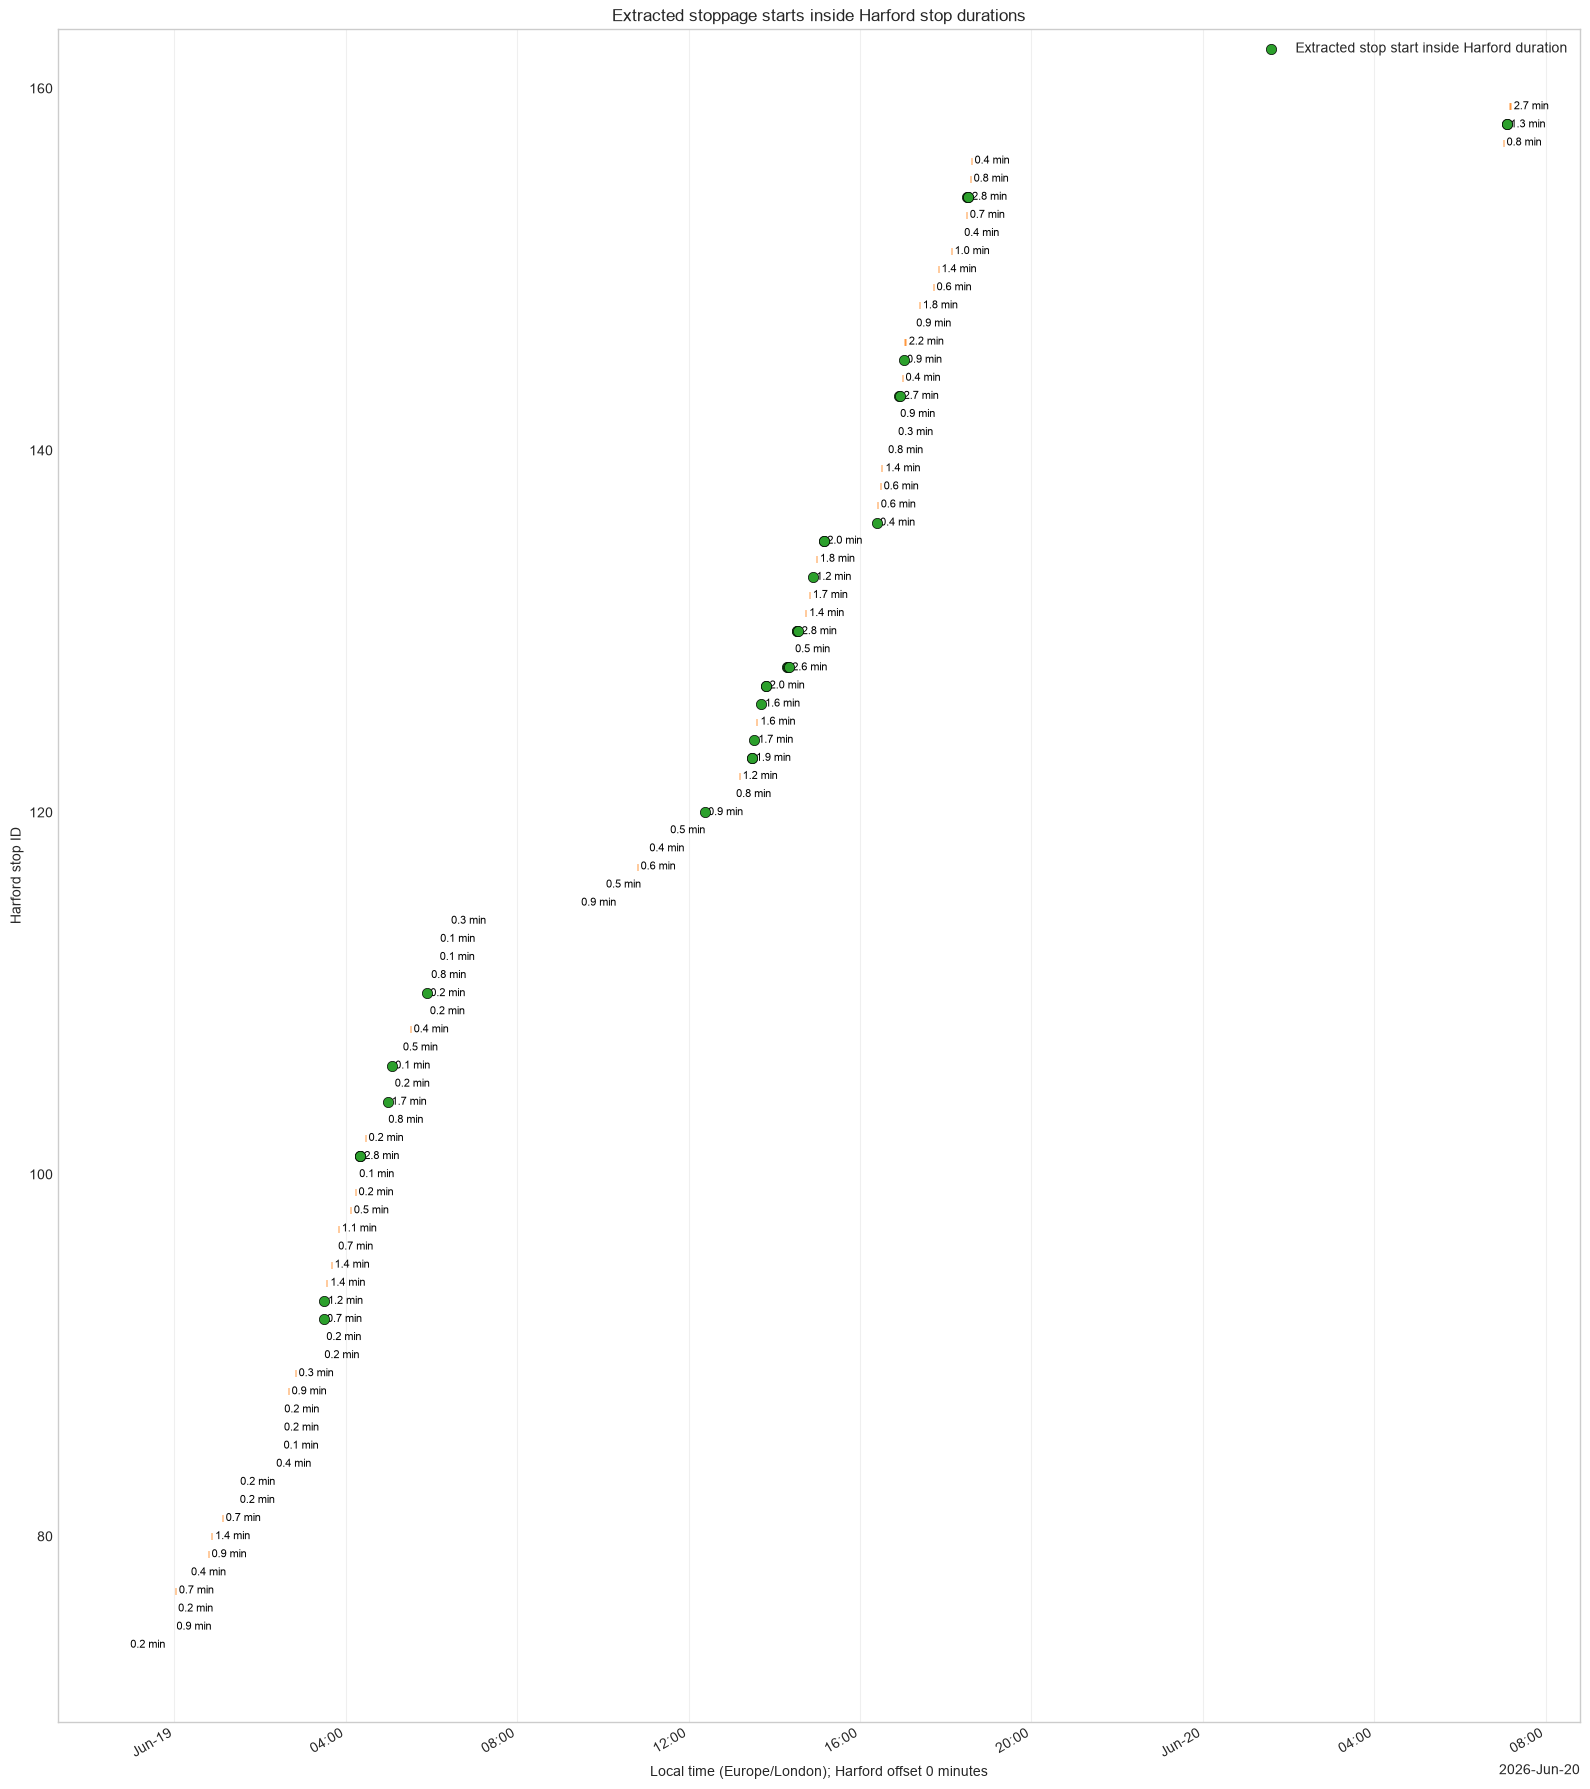

Harford time offset applied: 0 minutes
Shared comparison window: 2026-06-18 22:11:06.834444444 to 2026-06-20 08:05:57.833333333
Harford duration windows plotted: 86
Extracted stop starts checked: 257
Extracted stop starts inside Harford duration: 33
Saved simple graph to: C:\Users\TimKitchen\OneDrive\OneDrive - PurpleSector\03 Project Specific Documents\24H_INSIGHTS\24H_Insights\motion_detection\stoppage_analysis_output\simple_harford_duration_match_graph.png
Saved match rows to: C:\Users\TimKitchen\OneDrive\OneDrive - PurpleSector\03 Project Specific Documents\24H_INSIGHTS\24H_Insights\motion_detection\stoppage_analysis_output\extracted_stops_inside_harford_duration.csv
Saved summary to: C:\Users\TimKitchen\OneDrive\OneDrive - PurpleSector\03 Project Specific Documents\24H_INSIGHTS\24H_Insights\motion_detection\stoppage_analysis_output\simple_harford_duration_match_summary.csv


,metric,value
0,harford_time_offset,0 minutes
1,shared_window_start,2026-06-18 22:11:06.834444444
2,shared_window_end,2026-06-20 08:05:57.833333333
3,harford_duration_column,Time.1
4,harford_duration_windows_plotted,86
5,extracted_stop_starts_checked,257
6,extracted_stop_starts_inside_harford_duration,33
7,unique_harford_stops_containing_extracted_start,20


,extracted_interval_id,harford_stop_id,video_name,extracted_stop_start_time,extracted_stop_end_time,harford_stop_start_time,harford_stop_end_time,harford_duration_seconds_from_time_column,harford_duration_minutes_from_time_column,seconds_after_harford_start,seconds_before_harford_end
0,27,92,cortexvpu-01a-005-41884872_2026-06-19_02-28-45...,2026-06-19 03:28:48.061111111,2026-06-19 03:28:49.092222222,2026-06-19 03:28:41.976,2026-06-19 03:29:20.976,39.0,0.650000,6.085111,32.914888
1,28,93,cortexvpu-01a-005-41884872_2026-06-19_02-29-54...,2026-06-19 03:29:55.063333333,2026-06-19 03:29:56.416666667,2026-06-19 03:29:35.624,2026-06-19 03:30:47.624,72.0,1.200000,19.439333,52.560666
2,46,101,cortexvpu-01a-005-41884872_2026-06-19_03-19-09...,2026-06-19 04:19:11.062222222,2026-06-19 04:19:16.475555556,2026-06-19 04:18:49.333,2026-06-19 04:21:39.333,170.0,2.833333,21.729222,148.270777
3,47,101,cortexvpu-01a-005-41884872_2026-06-19_03-19-17...,2026-06-19 04:19:19.062222222,2026-06-19 04:19:28.475555556,2026-06-19 04:18:49.333,2026-06-19 04:21:39.333,170.0,2.833333,29.729222,140.270777
4,48,101,cortexvpu-01a-005-41884872_2026-06-19_03-19-58...,2026-06-19 04:20:04.025555556,2026-06-19 04:20:05.765555556,2026-06-19 04:18:49.333,2026-06-19 04:21:39.333,170.0,2.833333,74.692555,95.307444
5,55,104,cortexvpu-01a-005-41884872_2026-06-19_03-58-57...,2026-06-19 04:59:00.254444444,2026-06-19 04:59:10.501111111,2026-06-19 04:58:13.595,2026-06-19 04:59:55.595,102.0,1.700000,46.659444,55.340555
6,60,106,cortexvpu-01a-005-41884872_2026-06-19_04-04-49...,2026-06-19 05:04:51.062222222,2026-06-19 05:04:55.895555556,2026-06-19 05:04:44.454,2026-06-19 05:04:53.454,9.0,0.150000,6.608222,2.391777
7,69,110,cortexvpu-01a-005-41884872_2026-06-19_04-54-02...,2026-06-19 05:54:04.062222222,2026-06-19 05:54:05.512222222,2026-06-19 05:53:54.107,2026-06-19 05:54:04.107,10.0,0.166667,9.955222,0.044777
8,126,120,cortexvpu-01a-005-41884872_2026-06-19_11-21-59...,2026-06-19 12:22:23.750000000,2026-06-19 12:22:25.833333333,2026-06-19 12:22:03.263,2026-06-19 12:23:00.263,57.0,0.950000,20.487000,36.513000
9,142,123,cortexvpu-01a-005-41884872_2026-06-19_12-28-05...,2026-06-19 13:28:05.166666667,2026-06-19 13:28:08.166666667,2026-06-19 13:28:04.968,2026-06-19 13:29:55.968,111.0,1.850000,0.198666,110.801333


In [71]:
# Use the grouped extracted stoppages from Chapter 3.
# Each row is one extracted stoppage event after repeated detections have been grouped.
extracted_stop_interval_df = extracted_stops_df.copy()
extracted_stop_interval_df["video_name"] = extracted_stop_interval_df["source_first_video_name"]
extracted_stop_interval_df["extracted_interval_id"] = extracted_stop_interval_df["extracted_stop_id"]
extracted_stop_interval_df["extracted_stop_start_time"] = extracted_stop_interval_df["stop_time"]
extracted_stop_interval_df["extracted_stop_end_time"] = extracted_stop_interval_df["stop_end_time"]

# Build Harford stop windows from adjusted Harford time plus the duration column.
harford_stop_interval_df = harford_stops_df.copy()
harford_stop_interval_df["harford_stop_start_time"] = harford_stop_interval_df["harford_time"]
harford_stop_interval_df["harford_interval_seconds"] = harford_stop_interval_df["harford_duration_minutes"] * 60

# If a duration is missing, keep a one-second window so the row is still visible.
invalid_harford_duration = (
    harford_stop_interval_df["harford_interval_seconds"].isna()
    | (harford_stop_interval_df["harford_interval_seconds"] <= 0)
)
harford_stop_interval_df.loc[invalid_harford_duration, "harford_interval_seconds"] = 1

# Calculate each Harford stop end time from the duration.
harford_stop_interval_df["harford_stop_end_time"] = harford_stop_interval_df["harford_stop_start_time"] + pd.to_timedelta(
    harford_stop_interval_df["harford_interval_seconds"],
    unit="s",
)

# Compare only the time range where both datasets exist.
shared_window_start = max(
    extracted_stop_interval_df["extracted_stop_start_time"].min(),
    harford_stop_interval_df["harford_stop_start_time"].min(),
)
shared_window_end = min(
    extracted_stop_interval_df["extracted_stop_start_time"].max(),
    harford_stop_interval_df["harford_stop_end_time"].max(),
)

if shared_window_start >= shared_window_end:
    raise ValueError("Extracted and Harford records do not share a common time window")

# Keep only Harford windows that touch the shared comparison window.
harford_interval_window_df = harford_stop_interval_df[
    (harford_stop_interval_df["harford_stop_start_time"] < shared_window_end)
    & (harford_stop_interval_df["harford_stop_end_time"] > shared_window_start)
].copy()

# Keep only extracted starts inside the same comparison window.
extracted_start_window_df = extracted_stop_interval_df[
    (extracted_stop_interval_df["extracted_stop_start_time"] >= shared_window_start)
    & (extracted_stop_interval_df["extracted_stop_start_time"] <= shared_window_end)
].copy()

# Find extracted stop starts that fall inside a Harford duration window.
inside_harford_rows = []
for extracted_row in extracted_start_window_df.itertuples(index=False):
    containing_harford_df = harford_interval_window_df[
        (harford_interval_window_df["harford_stop_start_time"] <= extracted_row.extracted_stop_start_time)
        & (harford_interval_window_df["harford_stop_end_time"] >= extracted_row.extracted_stop_start_time)
    ]

    for harford_row in containing_harford_df.itertuples(index=False):
        seconds_after_harford_start = (
            extracted_row.extracted_stop_start_time - harford_row.harford_stop_start_time
        ).total_seconds()
        seconds_before_harford_end = (
            harford_row.harford_stop_end_time - extracted_row.extracted_stop_start_time
        ).total_seconds()

        inside_harford_rows.append({
            "extracted_interval_id": extracted_row.extracted_interval_id,
            "harford_stop_id": harford_row.harford_stop_id,
            "video_name": extracted_row.video_name,
            "extracted_stop_start_time": extracted_row.extracted_stop_start_time,
            "extracted_stop_end_time": extracted_row.extracted_stop_end_time,
            "harford_stop_start_time": harford_row.harford_stop_start_time,
            "harford_stop_end_time": harford_row.harford_stop_end_time,
            "harford_duration_seconds_from_time_column": harford_row.harford_interval_seconds,
            "harford_duration_minutes_from_time_column": harford_row.harford_interval_seconds / 60,
            "seconds_after_harford_start": seconds_after_harford_start,
            "seconds_before_harford_end": seconds_before_harford_end,
        })

extracted_inside_harford_df = pd.DataFrame(inside_harford_rows)

# Save the simple match table so the graph can be audited later.
extracted_inside_harford_path = output_dir / "extracted_stops_inside_harford_duration.csv"
extracted_inside_harford_df.to_csv(extracted_inside_harford_path, index=False)

# Save the Harford windows that were plotted.
harford_duration_windows_path = output_dir / "harford_duration_windows_for_graph.csv"
harford_interval_window_df.to_csv(harford_duration_windows_path, index=False)

# Save a compact summary.
simple_graph_summary_df = pd.DataFrame([
    ("harford_time_offset", HARFORD_TIME_OFFSET_LABEL),
    ("shared_window_start", shared_window_start),
    ("shared_window_end", shared_window_end),
    ("harford_duration_column", harford_duration_column),
    ("harford_duration_windows_plotted", len(harford_interval_window_df)),
    ("extracted_stop_starts_checked", len(extracted_start_window_df)),
    ("extracted_stop_starts_inside_harford_duration", len(extracted_inside_harford_df)),
    (
        "unique_harford_stops_containing_extracted_start",
        extracted_inside_harford_df["harford_stop_id"].nunique() if not extracted_inside_harford_df.empty else 0,
    ),
], columns=["metric", "value"])

simple_graph_summary_path = output_dir / "simple_harford_duration_match_summary.csv"
simple_graph_summary_df.to_csv(simple_graph_summary_path, index=False)

# Build a simple interval plot.
# Orange lines show Harford stop duration windows.
# Green dots show extracted stop starts that fall inside those windows.
simple_match_plot_path = output_dir / "simple_harford_duration_match_graph.png"
plot_height = max(6, min(18, len(harford_interval_window_df) * 0.28))
fig, ax = plt.subplots(figsize=(16, plot_height))

for row in harford_interval_window_df.itertuples(index=False):
    duration_minutes = row.harford_interval_seconds / 60

    ax.hlines(
        y=row.harford_stop_id,
        xmin=row.harford_stop_start_time,
        xmax=row.harford_stop_end_time,
        color="tab:orange",
        linewidth=5,
        alpha=0.8,
    )

    # Label the duration at the end of the Harford bar.
    ax.text(
        row.harford_stop_end_time,
        row.harford_stop_id,
        f" {duration_minutes:.1f} min",
        va="center",
        fontsize=8,
        color="black",
    )

if not extracted_inside_harford_df.empty:
    ax.scatter(
        extracted_inside_harford_df["extracted_stop_start_time"],
        extracted_inside_harford_df["harford_stop_id"],
        color="tab:green",
        edgecolors="black",
        linewidths=0.5,
        s=55,
        zorder=5,
        label="Extracted stop start inside Harford duration",
    )

ax.set_title("Extracted stoppage starts inside Harford stop durations")
ax.set_xlabel(f"Local time ({LOCAL_TIMEZONE}); Harford offset {HARFORD_TIME_OFFSET_LABEL}")
ax.set_ylabel("Harford stop ID")
ax.grid(True, axis="x", alpha=0.3)
ax.grid(False, axis="y")
ax.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=6, maxticks=10))
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))

if not extracted_inside_harford_df.empty:
    ax.legend(loc="upper right")

fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(simple_match_plot_path, dpi=180)
plt.show()

print(f"Harford time offset applied: {HARFORD_TIME_OFFSET_LABEL}")
print(f"Shared comparison window: {shared_window_start} to {shared_window_end}")
print(f"Harford duration windows plotted: {len(harford_interval_window_df)}")
print(f"Extracted stop starts checked: {len(extracted_start_window_df)}")
print(f"Extracted stop starts inside Harford duration: {len(extracted_inside_harford_df)}")
print(f"Saved simple graph to: {simple_match_plot_path}")
print(f"Saved match rows to: {extracted_inside_harford_path}")
print(f"Saved summary to: {simple_graph_summary_path}")

display(simple_graph_summary_df)
if not extracted_inside_harford_df.empty:
    display(extracted_inside_harford_df.head(20))


## 8. Pearson Correlation Scan on Grouped Stoppage Events

This section scans time offsets using grouped stoppage events rather than full stop durations.

- Each grouped extracted stoppage contributes one event at its grouped `stop_time`.
- Each Harford stoppage contributes one event at its adjusted `harford_time`.
- Each event is expanded into a small binary marker window so near misses still contribute to the correlation.
- The scan shifts extracted grouped events and calculates Pearson correlation against Harford grouped events.


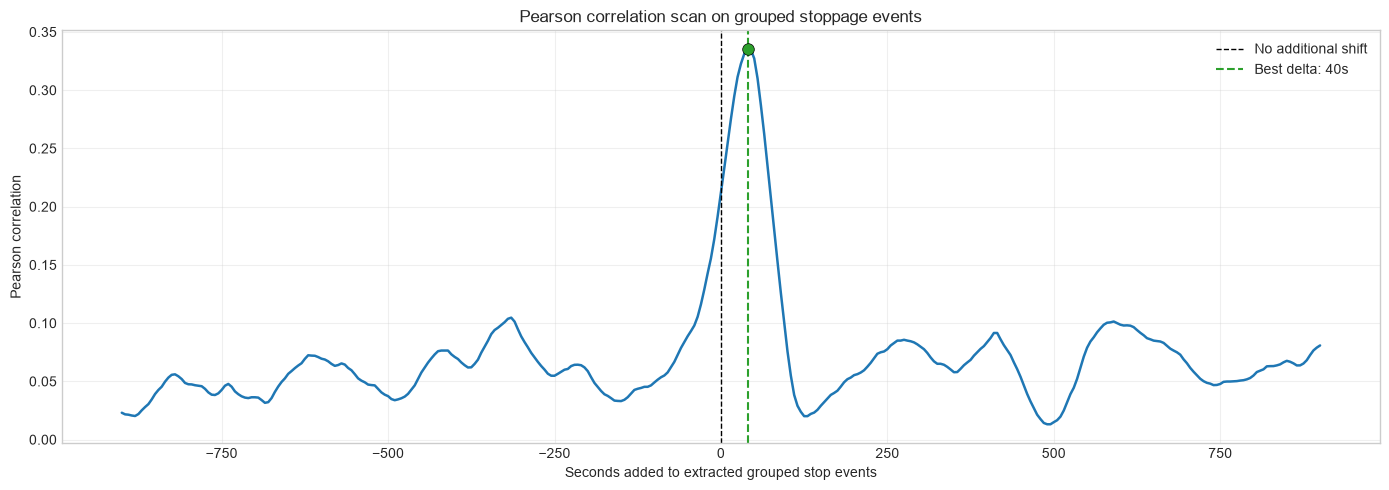

Grouped-event correlation window: 2026-06-18 22:11:06.834444444 to 2026-06-20 08:05:57.833333333
Grouped extracted events: 257
Harford events: 192
Event marker width: 60s
Scan range: -900s to 900s
Scan step: 5s
Best delta added to extracted grouped events: 40s
Best grouped-event Pearson correlation: 0.3352
Saved grouped-event correlation scan to: C:\Users\TimKitchen\OneDrive\OneDrive - PurpleSector\03 Project Specific Documents\24H_INSIGHTS\24H_Insights\motion_detection\stoppage_analysis_output\pearson_correlation_grouped_event_offset_scan.csv
Saved grouped-event correlation graph to: C:\Users\TimKitchen\OneDrive\OneDrive - PurpleSector\03 Project Specific Documents\24H_INSIGHTS\24H_Insights\motion_detection\stoppage_analysis_output\pearson_correlation_grouped_event_offset_scan.png


,delta_seconds_added_to_extracted_grouped_events,pearson_correlation,overlapping_marker_seconds,extracted_marker_seconds_after_shift,harford_marker_seconds,event_marker_width_seconds
188,40,0.335153,2896,12002,4970,60
189,45,0.334735,2893,12002,4970,60
187,35,0.331116,2867,12002,4970,60
190,50,0.327218,2839,12002,4970,60
186,30,0.322606,2806,12003,4970,60
185,25,0.311330,2725,12003,4970,60
191,55,0.310094,2716,12002,4970,60
184,20,0.294764,2606,12003,4970,60
192,60,0.287123,2551,12002,4970,60
183,15,0.275274,2466,12003,4970,60


In [41]:
# Configure the grouped-event scan range.
# Positive delta means extracted grouped stoppages are moved later before comparing to Harford.
# Negative delta means extracted grouped stoppages are moved earlier before comparing to Harford.
GROUPED_CORRELATION_SCAN_MIN_DELTA_SECONDS = -900
GROUPED_CORRELATION_SCAN_MAX_DELTA_SECONDS = 900
GROUPED_CORRELATION_SCAN_STEP_SECONDS = 5
GROUPED_CORRELATION_TIME_BIN_SECONDS = 1
GROUPED_EVENT_MARKER_WIDTH_SECONDS = 60


def build_grouped_event_marker_series(event_time_series, timeline_start, number_of_bins, bin_seconds, time_offset, marker_width_seconds):
    """Convert grouped event start times into a binary event-marker timeline."""
    # Start with every second marked as no grouped event nearby.
    marker_values = np.zeros(number_of_bins, dtype=np.int8)

    # Convert repeated numeric settings into Timedelta objects once.
    bin_width = pd.Timedelta(seconds=bin_seconds)
    half_marker_width = pd.Timedelta(seconds=marker_width_seconds / 2)

    for event_time in event_time_series.dropna():
        # Shift the event by the delta being tested.
        shifted_event_time = event_time + time_offset

        # Expand one grouped event into a short marker window around its start time.
        marker_start_time = shifted_event_time - half_marker_width
        marker_end_time = shifted_event_time + half_marker_width

        # Convert the marker window into integer bin positions.
        start_bin = int(np.floor((marker_start_time - timeline_start) / bin_width))
        end_bin = int(np.ceil((marker_end_time - timeline_start) / bin_width))

        # Clip the marker to the comparison timeline.
        start_bin = max(start_bin, 0)
        end_bin = min(end_bin, number_of_bins)

        # Skip markers that sit fully outside the comparison timeline.
        if end_bin <= start_bin:
            continue

        # Mark bins close to this grouped event as active.
        marker_values[start_bin:end_bin] = 1

    return marker_values


# Use grouped extracted stoppage starts from Chapter 3.
grouped_extracted_event_times = extracted_stops_df["stop_time"].dropna().copy()

# Use adjusted Harford stoppage starts from Chapter 4.
grouped_harford_event_times = harford_stops_df["harford_time"].dropna().copy()

# Use a fixed comparison window so every tested delta is scored against the same period.
grouped_correlation_window_start = max(
    grouped_extracted_event_times.min(),
    grouped_harford_event_times.min(),
)
grouped_correlation_window_end = min(
    grouped_extracted_event_times.max(),
    grouped_harford_event_times.max(),
)

if grouped_correlation_window_start >= grouped_correlation_window_end:
    raise ValueError("Grouped extracted and Harford events do not share a common correlation window")

# Convert the comparison window into one-second bins.
grouped_correlation_window_seconds = (
    grouped_correlation_window_end - grouped_correlation_window_start
).total_seconds()
number_of_grouped_correlation_bins = int(
    np.ceil(grouped_correlation_window_seconds / GROUPED_CORRELATION_TIME_BIN_SECONDS)
)

# Build the Harford grouped-event marker timeline once because Harford is not shifted.
harford_grouped_marker_values = build_grouped_event_marker_series(
    grouped_harford_event_times,
    grouped_correlation_window_start,
    number_of_grouped_correlation_bins,
    GROUPED_CORRELATION_TIME_BIN_SECONDS,
    pd.Timedelta(seconds=0),
    GROUPED_EVENT_MARKER_WIDTH_SECONDS,
)

# Scan extracted grouped-event offsets and calculate Pearson correlation at each offset.
grouped_correlation_rows = []
for delta_seconds in range(
    GROUPED_CORRELATION_SCAN_MIN_DELTA_SECONDS,
    GROUPED_CORRELATION_SCAN_MAX_DELTA_SECONDS + GROUPED_CORRELATION_SCAN_STEP_SECONDS,
    GROUPED_CORRELATION_SCAN_STEP_SECONDS,
):
    # Shift extracted grouped events by the current candidate delta.
    extracted_time_offset = pd.Timedelta(seconds=delta_seconds)
    extracted_grouped_marker_values = build_grouped_event_marker_series(
        grouped_extracted_event_times,
        grouped_correlation_window_start,
        number_of_grouped_correlation_bins,
        GROUPED_CORRELATION_TIME_BIN_SECONDS,
        extracted_time_offset,
        GROUPED_EVENT_MARKER_WIDTH_SECONDS,
    )

    # Pearson correlation is only valid when both binary timelines have variation.
    harford_has_variation = harford_grouped_marker_values.min() != harford_grouped_marker_values.max()
    extracted_has_variation = extracted_grouped_marker_values.min() != extracted_grouped_marker_values.max()
    if harford_has_variation and extracted_has_variation:
        pearson_correlation = np.corrcoef(harford_grouped_marker_values, extracted_grouped_marker_values)[0, 1]
    else:
        pearson_correlation = np.nan

    # Count marker overlap as an easier-to-read companion metric.
    overlapping_marker_seconds = int(
        ((harford_grouped_marker_values == 1) & (extracted_grouped_marker_values == 1)).sum()
    )
    extracted_marker_seconds = int(extracted_grouped_marker_values.sum())
    harford_marker_seconds = int(harford_grouped_marker_values.sum())

    grouped_correlation_rows.append({
        "delta_seconds_added_to_extracted_grouped_events": delta_seconds,
        "pearson_correlation": pearson_correlation,
        "overlapping_marker_seconds": overlapping_marker_seconds * GROUPED_CORRELATION_TIME_BIN_SECONDS,
        "extracted_marker_seconds_after_shift": extracted_marker_seconds * GROUPED_CORRELATION_TIME_BIN_SECONDS,
        "harford_marker_seconds": harford_marker_seconds * GROUPED_CORRELATION_TIME_BIN_SECONDS,
        "event_marker_width_seconds": GROUPED_EVENT_MARKER_WIDTH_SECONDS,
    })

grouped_correlation_scan_df = pd.DataFrame(grouped_correlation_rows)

# Find the offset with the strongest grouped-event correlation.
valid_grouped_correlation_df = grouped_correlation_scan_df.dropna(subset=["pearson_correlation"]).copy()
if valid_grouped_correlation_df.empty:
    raise ValueError("Pearson correlation could not be calculated because one grouped-event timeline has no variation")

best_grouped_correlation_row = valid_grouped_correlation_df.loc[
    valid_grouped_correlation_df["pearson_correlation"].idxmax()
]
best_grouped_delta_seconds = int(best_grouped_correlation_row["delta_seconds_added_to_extracted_grouped_events"])
best_grouped_correlation_value = float(best_grouped_correlation_row["pearson_correlation"])

# Save the grouped-event scan results.
grouped_correlation_scan_path = output_dir / "pearson_correlation_grouped_event_offset_scan.csv"
grouped_correlation_scan_plot_path = output_dir / "pearson_correlation_grouped_event_offset_scan.png"
grouped_correlation_scan_df.to_csv(grouped_correlation_scan_path, index=False)

# Plot correlation strength against tested time delta.
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(
    grouped_correlation_scan_df["delta_seconds_added_to_extracted_grouped_events"],
    grouped_correlation_scan_df["pearson_correlation"],
    color="tab:blue",
    linewidth=1.8,
)
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="No additional shift")
ax.axvline(
    best_grouped_delta_seconds,
    color="tab:green",
    linewidth=1.5,
    linestyle="--",
    label=f"Best delta: {best_grouped_delta_seconds}s",
)
ax.scatter(
    [best_grouped_delta_seconds],
    [best_grouped_correlation_value],
    color="tab:green",
    edgecolors="black",
    linewidths=0.5,
    s=70,
    zorder=5,
)
ax.set_title("Pearson correlation scan on grouped stoppage events")
ax.set_xlabel("Seconds added to extracted grouped stop events")
ax.set_ylabel("Pearson correlation")
ax.grid(True, alpha=0.3)
ax.legend(loc="best")
fig.tight_layout()
fig.savefig(grouped_correlation_scan_plot_path, dpi=180)
plt.show()

print(f"Grouped-event correlation window: {grouped_correlation_window_start} to {grouped_correlation_window_end}")
print(f"Grouped extracted events: {len(grouped_extracted_event_times)}")
print(f"Harford events: {len(grouped_harford_event_times)}")
print(f"Event marker width: {GROUPED_EVENT_MARKER_WIDTH_SECONDS}s")
print(f"Scan range: {GROUPED_CORRELATION_SCAN_MIN_DELTA_SECONDS}s to {GROUPED_CORRELATION_SCAN_MAX_DELTA_SECONDS}s")
print(f"Scan step: {GROUPED_CORRELATION_SCAN_STEP_SECONDS}s")
print(f"Best delta added to extracted grouped events: {best_grouped_delta_seconds}s")
print(f"Best grouped-event Pearson correlation: {best_grouped_correlation_value:.4f}")
print(f"Saved grouped-event correlation scan to: {grouped_correlation_scan_path}")
print(f"Saved grouped-event correlation graph to: {grouped_correlation_scan_plot_path}")

display(grouped_correlation_scan_df.sort_values("pearson_correlation", ascending=False).head(10))
